# TFG - Análisis de Datos

### Estimación de rendimiento de cultivos utilizando inteligencia artificial y datos de observación de la tierra

##### Nacor Olmos Caballero

## Librerías

In [102]:
import pandas as pd
import numpy as np
import rasterio
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterstats
from rasterstats import zonal_stats
import folium
import branca.colormap as cm
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import textwrap

import os
os.makedirs("Figuras", exist_ok=True)
os.makedirs("CleanData", exist_ok=True)

## Tratamiento de Datos

#### Máscaras por cultivo

In [103]:
# Máscaras por cultivo
EXT_Maize = pd.read_csv("./Data/LUT/EXT_Maize(corn).csv")
EXT_Rice = pd.read_csv("./Data/LUT/EXT_Rice.csv")
EXT_Wheat = pd.read_csv("./Data/LUT/EXT_Wheat.csv")

print(EXT_Maize.head())
print(EXT_Maize.info())
print("--------------------------------------")
print(EXT_Rice.head())
print(EXT_Rice.info())
print("--------------------------------------")
print(EXT_Wheat.head())
print(EXT_Wheat.info())

   asap0_id     name0_shr          item                 option1  \
0        29         Sudan  Maize (corn)  FAO GYF - Maize (corn)   
1       208     Australia  Maize (corn)  FAO GYF - Maize (corn)   
2       145  Russian Fed.  Maize (corn)  FAO GYF - Maize (corn)   
3        96       Eritrea  Maize (corn)  FAO GYF - Maize (corn)   
4       185      Ethiopia  Maize (corn)  FAO GYF - Maize (corn)   

                     option2                  option3  
0  FAO GYF - Maize (corn) WC  FAO GYF - Multiple ASAP  
1  FAO GYF - Maize (corn) WC  FAO GYF - Multiple ASAP  
2  FAO GYF - Maize (corn) WC  FAO GYF - Multiple ASAP  
3  FAO GYF - Maize (corn) WC  FAO GYF - Multiple ASAP  
4  FAO GYF - Maize (corn) WC  FAO GYF - Multiple ASAP  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   asap0_id   220 non-null    int64 
 1   name0_shr  220 non-null    object
 

In [104]:
# Eliminamos datos faltantes
EXT_Maize = EXT_Maize.dropna()
EXT_Rice = EXT_Rice.dropna()
EXT_Wheat = EXT_Wheat.dropna()

In [105]:
# Nos quedamos solo con la máscara de mejor calidad (option1)
EXT_Maize = EXT_Maize[["asap0_id", "name0_shr", "option1"]].rename(columns={"option1": "mask_name"})
EXT_Rice = EXT_Rice[["asap0_id", "name0_shr", "option1"]].rename(columns={"option1": "mask_name"})
EXT_Wheat = EXT_Wheat[["asap0_id", "name0_shr", "option1"]].rename(columns={"option1": "mask_name"})

Los DataFrame resultantes contienen, para cada cultivo:

· ASAP ID

· Nombre del país

· Mejor máscara

####  Variables climáticas y de teledetección

In [106]:
# Variables climáticas y de teledetección
mult_crops = pd.read_csv(".\Data\GAUL0-MultipleCrop-ASAP-ASIS_v7.0.csv\GAUL0-MultipleCrop-ASAP-ASIS_v7.0.csv")

print(mult_crops)

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Nacor Olmos\AppData\Local\Temp\ipykernel_26128\3694393113.py:2: SyntaxWarning: invalid escape sequence '\D'
  mult_crops = pd.read_csv(".\Data\GAUL0-MultipleCrop-ASAP-ASIS_v7.0.csv\GAUL0-MultipleCrop-ASAP-ASIS_v7.0.csv")


                  id     dekad  asap_unit_id  fao_unit_id     unit_name  \
0         75888438.0  19870311           141          227  South Africa   
1         75610272.0  19870301           141          227  South Africa   
2         76139322.0  19870321           141          227  South Africa   
3         75335001.0  19870221           141          227  South Africa   
4         75070115.0  19870211           141          227  South Africa   
...              ...       ...           ...          ...           ...   
4403653  157875468.0  20230801            35           63          Cuba   
4403654   63746416.0  20230701            35           63          Cuba   
4403655   64369418.0  20230721            35           63          Cuba   
4403656   64054774.0  20230711            35           63          Cuba   
4403657   63121111.0  20230611            35           63          Cuba   

        adm_unit_layer  extraction_setup_id extraction_setup_name  \
0           GAUL0_v8.0        

In [107]:
print(mult_crops.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4403658 entries, 0 to 4403657
Data columns (total 20 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   id                               float64
 1   dekad                            int64  
 2   asap_unit_id                     int64  
 3   fao_unit_id                      int64  
 4   unit_name                        object 
 5   adm_unit_layer                   object 
 6   extraction_setup_id              int64  
 7   extraction_setup_name            object 
 8   indicator_id                     int64  
 9   indicator_name                   object 
 10  mask_id                          int64  
 11  mask_name                        object 
 12  mask_path                        object 
 13  mean                             float64
 14  std                              float64
 15  px_cnt_total                     float64
 16  px_cnt_valid_data                float64
 17  px_cnt_v

In [108]:
mult_crops.describe()

,id,dekad,asap_unit_id,fao_unit_id,extraction_setup_id,indicator_id,mask_id,mean,std,px_cnt_total,px_cnt_valid_data,px_cnt_valid_data_after_masking,px_cnt_weight_sum,px_cnt_weight_sum_used
count,4.399269e+06,4.403658e+06,4.403658e+06,4.403658e+06,4.403658e+06,4.403658e+06,4.403658e+06,4.399269e+06,4.399269e+06,4.399269e+06,4.399269e+06,4.399269e+06,4.399269e+06,4.399269e+06
mean,7.416107e+07,2.004247e+07,1.241093e+02,7.419892e+02,2.944471e+01,3.252078e+01,2.544471e+01,2.490879e+04,1.383939e+03,4.453187e+06,4.069438e+06,4.557334e+05,1.340250e+07,1.305079e+07
std,4.054367e+07,1.148446e+05,5.636573e+01,4.927056e+03,8.805237e+00,1.539743e+01,8.805237e+00,6.613092e+04,4.231627e+03,1.593545e+07,1.476289e+07,1.025092e+06,4.304592e+07,4.118370e+07
min,1.680882e+07,1.984010e+07,1.000000e+00,1.000000e+00,1.200000e+01,9.000000e+00,8.000000e+00,-2.702640e+01,0.000000e+00,4.687600e+04,6.600000e+01,1.000000e+00,2.000000e+00,1.000000e+00
25%,4.534547e+07,1.994111e+07,8.000000e+01,6.700000e+01,2.000000e+01,1.200000e+01,1.600000e+01,3.200231e-01,6.018598e-02,5.073890e+05,4.765150e+05,4.684000e+04,5.808990e+05,5.580630e+05
50%,6.525404e+07,2.005012e+07,1.260000e+02,1.380000e+02,3.300000e+01,3.400000e+01,2.900000e+01,2.965020e+01,5.395974e+00,1.769091e+06,1.351541e+06,1.579190e+05,2.555356e+06,2.448814e+06
75%,8.826971e+07,2.014072e+07,1.680000e+02,2.050000e+02,3.700000e+01,4.800000e+01,3.300000e+01,1.514139e+02,2.161819e+01,3.855282e+06,3.680656e+06,4.592830e+05,1.017491e+07,9.829880e+06
max,1.600960e+08,2.024021e+07,2.210000e+02,4.076500e+04,3.900000e+01,5.000000e+01,3.500000e+01,3.585346e+05,7.580880e+04,1.465237e+08,1.426761e+08,1.381342e+07,8.396847e+08,8.295760e+08


In [109]:
print(mult_crops.isnull().sum())

id                                 4389
dekad                                 0
asap_unit_id                          0
fao_unit_id                           0
unit_name                             0
adm_unit_layer                        0
extraction_setup_id                   0
extraction_setup_name                 0
indicator_id                          0
indicator_name                        0
mask_id                               0
mask_name                             0
mask_path                             0
mean                               4389
std                                4389
px_cnt_total                       4389
px_cnt_valid_data                  4389
px_cnt_valid_data_after_masking    4389
px_cnt_weight_sum                  4389
px_cnt_weight_sum_used             4389
dtype: int64


In [110]:
mult_crops = mult_crops.dropna()

# Extraemos los años de la columna 'dekad'
mult_crops["year"] = mult_crops["dekad"] // 10000

In [111]:
# Nos quedamos con los campos de interés
camp_int = ["asap_unit_id", "year", "extraction_setup_name", "unit_name", "mask_name", "indicator_name", "mean", "std", "px_cnt_valid_data", "px_cnt_valid_data_after_masking"]
mult_crops = mult_crops[camp_int]

El DataFrame resultante contiene:

· ASAP ID & Nombre del país

· Año

· Variables de interés por máscara de cultivo

#### Ejemplo de extracción con Argentina:

In [112]:
# Filtramos por nombre de país
nom_pais = "Argentina"
df_arg = EXT_Maize[EXT_Maize['name0_shr'] == nom_pais]
print(df_arg, "\n")

# Obtenemos id y máscara de Argentina
id_arg = df_arg["asap0_id"].iloc[0]
mask_arg = df_arg["mask_name"].iloc[0]
print(f"ID {nom_pais}:", id_arg, "\nMejor máscara:", mask_arg)

    asap0_id  name0_shr               mask_name
37       166  Argentina  FAO GYF - Maize (corn) 

ID Argentina: 166 
Mejor máscara: FAO GYF - Maize (corn)


In [113]:
print(type(id_arg))
print(type(mask_arg))

<class 'numpy.int64'>
<class 'str'>


In [114]:
# Obtenemos los datos de Argentina
df_arg_data = mult_crops[(mult_crops['asap_unit_id'] == id_arg) & (mult_crops['extraction_setup_name'] == mask_arg)]
print(df_arg_data.head())

        asap_unit_id  year   extraction_setup_name  unit_name  \
800395           166  1984  FAO GYF - Maize (corn)  Argentina   
800396           166  1984  FAO GYF - Maize (corn)  Argentina   
800397           166  1984  FAO GYF - Maize (corn)  Argentina   
800398           166  1984  FAO GYF - Maize (corn)  Argentina   
800399           166  1984  FAO GYF - Maize (corn)  Argentina   

                      mask_name indicator_name        mean       std  \
800395  FAO GYF -  Maize (corn)       ASIS:BT4  149.705272  4.279921   
800396  FAO GYF -  Maize (corn)       ASIS:BT4  147.627518  3.571184   
800397  FAO GYF -  Maize (corn)       ASIS:BT4  152.094420  5.229793   
800398  FAO GYF -  Maize (corn)       ASIS:BT4  151.559037  5.149593   
800399  FAO GYF -  Maize (corn)       ASIS:BT4  152.655800  5.514985   

        px_cnt_valid_data  px_cnt_valid_data_after_masking  
800395         13685626.0                        2379683.0  
800396         13685626.0                        23796

In [115]:
df_arg_data.dtypes

asap_unit_id                         int64
year                                 int64
extraction_setup_name               object
unit_name                           object
mask_name                           object
indicator_name                      object
mean                               float64
std                                float64
px_cnt_valid_data                  float64
px_cnt_valid_data_after_masking    float64
dtype: object

El DataFrame resultante contiene, para el tipo de cultivo y país seleccionado (Argentina/Maíz):

· ASAP ID (solo el del país seleccionado)

· Año

· Variables de interés (solo para la mejor máscara)

#### Inspeccionamos archivos '.tif'

In [116]:
# Lista de archivos .tif
archivos_tif = ["Data/koppen_geiger_tif/1991_2020/koppen_geiger_0p1.tif", "Data/koppen_geiger_tif/1991_2020/koppen_geiger_0p5.tif", "Data/koppen_geiger_tif/1991_2020/koppen_geiger_1p0.tif"]

for archivo in archivos_tif:
    with rasterio.open(archivo) as src:
        print(f"Archivo: {archivo}")
        print(f"  - Dimensiones (Alto x Ancho): {src.height} x {src.width}")
        print(f"  - Número de bandas: {src.count}")
        print(f"  - Sistema de coordenadas: {src.crs}")
        print(f"  - Extensión (bounds): {src.bounds}")
        print(f"  - Tipo de datos: {src.dtypes[0]}")
        print("-" * 50)


Archivo: Data/koppen_geiger_tif/1991_2020/koppen_geiger_0p1.tif
  - Dimensiones (Alto x Ancho): 1800 x 3600
  - Número de bandas: 1
  - Sistema de coordenadas: EPSG:4326
  - Extensión (bounds): BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
  - Tipo de datos: uint8
--------------------------------------------------
Archivo: Data/koppen_geiger_tif/1991_2020/koppen_geiger_0p5.tif
  - Dimensiones (Alto x Ancho): 360 x 720
  - Número de bandas: 1
  - Sistema de coordenadas: EPSG:4326
  - Extensión (bounds): BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
  - Tipo de datos: uint8
--------------------------------------------------
Archivo: Data/koppen_geiger_tif/1991_2020/koppen_geiger_1p0.tif
  - Dimensiones (Alto x Ancho): 180 x 360
  - Número de bandas: 1
  - Sistema de coordenadas: EPSG:4326
  - Extensión (bounds): BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
  - Tipo de datos: uint8
--------------------------------------------------


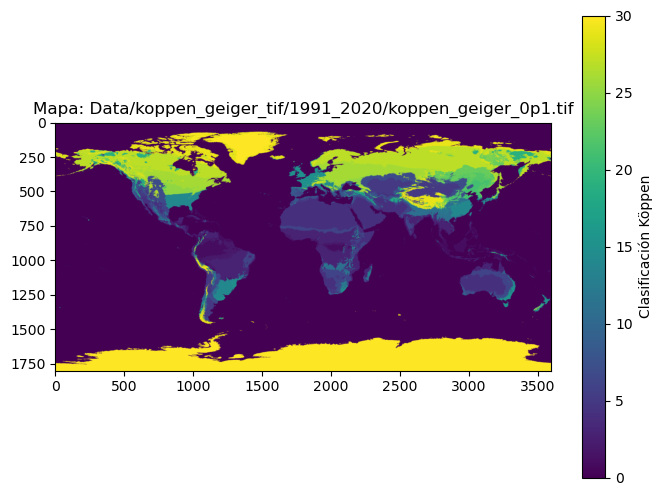

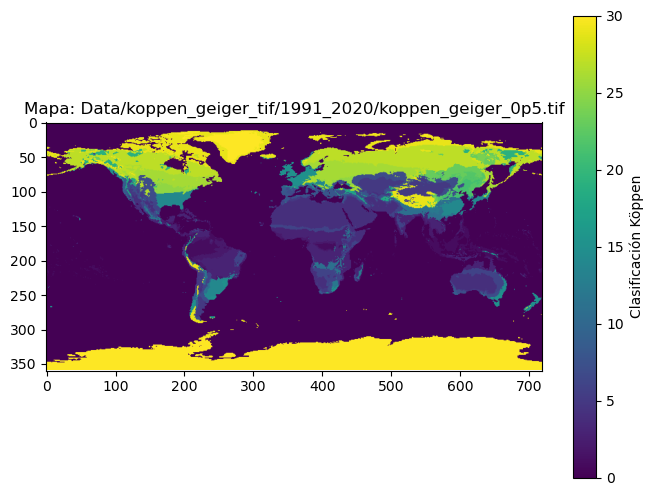

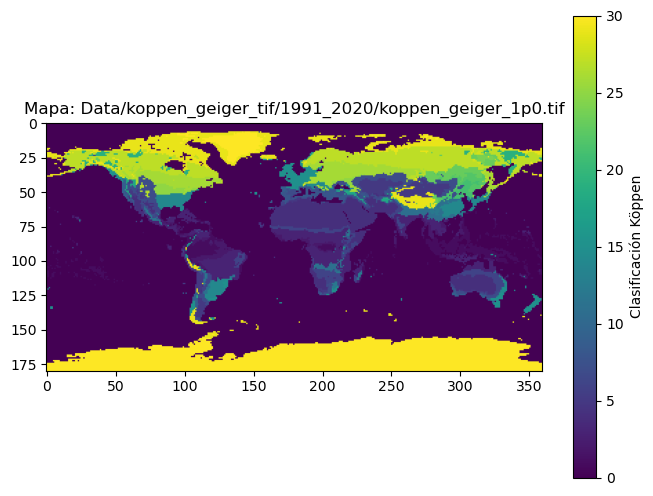

In [117]:

def visualizar_raster(ruta_tif, titulo="Raster"):
    with rasterio.open(ruta_tif) as src:
        raster_data = src.read(1)  # Leer la primera banda

    plt.figure(figsize=(8, 6))
    plt.imshow(raster_data, cmap="viridis")
    plt.colorbar(label="Clasificación Köppen")
    plt.title(titulo)
    plt.show()

# Mostrar todos los rasters
for archivo in archivos_tif:
    visualizar_raster(archivo, titulo=f"Mapa: {archivo}")

In [118]:
def valores_unicos_raster(ruta_tif):
    with rasterio.open(ruta_tif) as src:
        raster_data = src.read(1)  # Leer la primera banda
        valores_unicos = np.unique(raster_data)
    return valores_unicos

for archivo in archivos_tif:
    print(f"{archivo} - Valores únicos:", valores_unicos_raster(archivo))

Data/koppen_geiger_tif/1991_2020/koppen_geiger_0p1.tif - Valores únicos: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]
Data/koppen_geiger_tif/1991_2020/koppen_geiger_0p5.tif - Valores únicos: [ 0  1  2  3  4  5  6  7  8  9 11 12 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30]
Data/koppen_geiger_tif/1991_2020/koppen_geiger_1p0.tif - Valores únicos: [ 0  1  2  3  4  5  6  7  8  9 11 12 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30]


Usaremos el archivo 'koppen_geiger_0p1.tif' para la clasificación climática.

CRS del Raster: EPSG:4326
CRS del Shapefile: EPSG:4326
Extensión del Raster: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
Extensión del Shapefile: [-180.          -55.7948999   180.           83.62741852]


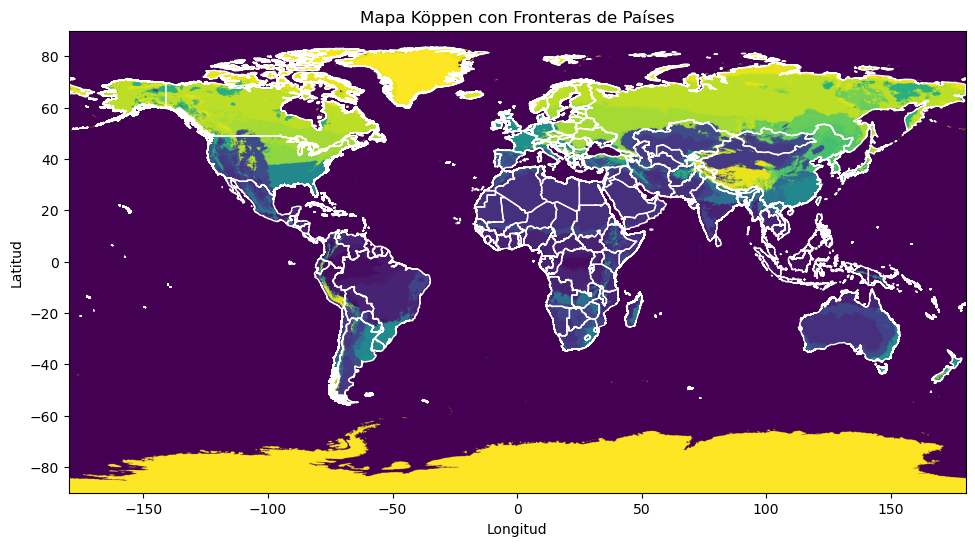

In [119]:
ruta_tif = "Data/koppen_geiger_tif/1991_2020/koppen_geiger_0p1.tif"
ruta_shapefile = "Data/gaul0_asap_shapefile/gaul0_asap.shp"

# Abrir el archivo raster
with rasterio.open(ruta_tif) as src:
    raster_data = src.read(1)  # Leer la primera banda
    raster_transform = src.transform  # Obtener la transformación espacial
    raster_crs = src.crs  # Obtener el sistema de coordenadas
    raster_bounds = src.bounds  # Obtener los límites del raster
    raster_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]  # Ajustar coordenadas


# Leer shapefile
gdf_paises = gpd.read_file(ruta_shapefile)
shapefile_crs = gdf_paises.crs
shapefile_bounds = gdf_paises.total_bounds  # (xmin, ymin, xmax, ymax)

# Mostrar información
print("CRS del Raster:", raster_crs)
print("CRS del Shapefile:", shapefile_crs)
print("Extensión del Raster:", raster_bounds)
print("Extensión del Shapefile:", shapefile_bounds)

# Graficar el raster con su extensión correcta
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(raster_data, cmap="viridis", extent=raster_extent)  # Ajustamos la extensión
gdf_paises.boundary.plot(ax=ax, edgecolor="white", linewidth=1)  # Dibujar países
plt.title("Mapa Köppen con Fronteras de Países")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

In [120]:
print("Columnas en gdf_paises:", gdf_paises.columns)
print("Número de países en gdf_paises:", len(gdf_paises))
print(gdf_paises[['adm0_name', 'adm0_name_']])

Columnas en gdf_paises: Index(['adm0_code', 'adm0_name', 'adm0_name_', 'area_tot', 'area_crop',
       'area_pastu', 'asap0_id', 'isocode', 'isocode3', 'geometry'],
      dtype='object')
Número de países en gdf_paises: 220
                                        adm0_name     adm0_name_
0                Saint Vincent and the Grenadines  Saint Vincent
1                                      Cape Verde     Cape Verde
2                                           Spain          Spain
3                                           Qatar          Qatar
4    South Georgia and the South Sandwich Islands  South Georgia
..                                            ...            ...
215                                        France         France
216                                     Indonesia      Indonesia
217                                          Cuba           Cuba
218                                       Bolivia        Bolivia
219                                        Canada         Cana

In [121]:
# Calcular estadísticas del raster dentro de cada país
estadisticas = zonal_stats(gdf_paises, ruta_tif, stats=["majority"], categorical=True)

# Agregar la clasificación Köppen predominante al GeoDataFrame
gdf_paises["koppen_class"] = [stat.get("majority", None) for stat in estadisticas]

# Mostrar los primeros resultados
gdf_paises[["adm0_name", "koppen_class"]].head()

,adm0_name,koppen_class
0,Saint Vincent and the Grenadines,1.0
1,Cape Verde,4.0
2,Spain,7.0
3,Qatar,4.0
4,South Georgia and the South Sandwich Islands,29.0


In [122]:
gdf_paises[["adm0_name", "koppen_class"]].dtypes

adm0_name        object
koppen_class    float64
dtype: object

In [123]:
print("Clases Köppen únicas:", gdf_paises["koppen_class"].unique())
print("Número de clases Köppen:", gdf_paises["koppen_class"].nunique())


Clases Köppen únicas: [ 1.  4.  7. 29.  6.  3.  8. 26.  5. 27.  2. 15. 11. 25. 12. 14. 21. 30.
 16.]
Número de clases Köppen: 19


##### Descomentar la siguiente celda para visualizar Clasificación Climática Köppen

In [124]:
# # Crear mapa centrado en el mundo
# m = folium.Map(location=[0, 0], zoom_start=2)

# # Crear una paleta de colores basada en los valores únicos de koppen_class
# koppen_classes = gdf_paises["koppen_class"].unique()
# colormap = cm.linear.Set1_09.scale(0, len(koppen_classes)) # Paleta de colores

# # Crear un diccionario que asigna un color a cada clase Köppen
# color_dict = {koppen: colormap(i) for i, koppen in enumerate(koppen_classes)}

# # Añadir los países al mapa con colores diferenciados
# for _, row in gdf_paises.iterrows():
#     color = color_dict.get(row["koppen_class"], "#808080")  # Si no encuentra la clase, usa gris
#     folium.GeoJson(
#         row.geometry,
#         style_function=lambda x, color=color: {"fillColor": color, "color": "black", "weight": 0.5}
#     ).add_to(m)

# # Añadir la leyenda
# colormap.caption = "Clasificación Köppen"
# m.add_child(colormap)

# # Mostrar el mapa
# m

In [125]:
nom_pais = "Argentina"
gdf_paises.loc[gdf_paises["adm0_name"] == nom_pais, ["koppen_class"]]

,koppen_class
156,5.0


Una vez clasificado cada país con su clase climática Köppen, creamos un DataFrame con esos datos y hacemos merge con los datos de interés por máscara.

In [126]:
# Comprobamos valores faltantes
print("Valores faltantes en gdf_paises:", gdf_paises.isnull().sum())
 

# Creamos Data Frame con el ID del país y su clasificación Köppen
df_clima = gdf_paises[["asap0_id", "koppen_class"]].dropna()
df_clima["koppen_class"] = df_clima["koppen_class"].astype(int)  # Convertimos a entero


# Unimos con el DataFrame de cultivos
df_clima = df_clima.rename(columns={"asap0_id": "asap_unit_id"}) # Renombramos la columna para hacer 'merge'

df_crops_clima = mult_crops.merge(df_clima, on = "asap_unit_id", how = "left")
print("Valores faltantes en df_crops_clima:", df_crops_clima.isnull().sum())

Valores faltantes en gdf_paises: adm0_code        0
adm0_name        0
adm0_name_       0
area_tot         0
area_crop        0
area_pastu       0
asap0_id         0
isocode         14
isocode3        15
geometry         0
koppen_class     0
dtype: int64
Valores faltantes en df_crops_clima: asap_unit_id                       0
year                               0
extraction_setup_name              0
unit_name                          0
mask_name                          0
indicator_name                     0
mean                               0
std                                0
px_cnt_valid_data                  0
px_cnt_valid_data_after_masking    0
koppen_class                       0
dtype: int64


In [127]:
df_crops_clima 

,asap_unit_id,year,extraction_setup_name,unit_name,mask_name,indicator_name,mean,std,px_cnt_valid_data,px_cnt_valid_data_after_masking,koppen_class
0,141,1987,FAO GYF - Wheat,South Africa,FAO GYF - Wheat,ASAP:rad,194564.395886,17878.113489,5674374.0,545926.0,7
1,141,1987,FAO GYF - Wheat,South Africa,FAO GYF - Wheat,ASAP:rad,221987.275212,34437.290185,5674374.0,545926.0,7
2,141,1987,FAO GYF - Wheat,South Africa,FAO GYF - Wheat,ASAP:rad,212497.402436,20577.557032,5674374.0,545926.0,7
3,141,1987,FAO GYF - Wheat,South Africa,FAO GYF - Wheat,ASAP:rad,186331.566387,13043.660840,5674374.0,545926.0,7
4,141,1987,FAO GYF - Wheat,South Africa,FAO GYF - Wheat,ASAP:rad,235042.423980,30567.257030,5674374.0,545926.0,7
...,...,...,...,...,...,...,...,...,...,...,...
4399264,35,2023,FAO GYF - Beans dry,Cuba,FAO GYF - Beans dry,ASAP:rad,237139.221850,6233.918515,478271.0,124885.0,3
4399265,35,2023,FAO GYF - Beans dry,Cuba,FAO GYF - Beans dry,ASAP:rad,238502.944310,4868.815292,478271.0,124885.0,3
4399266,35,2023,FAO GYF - Beans dry,Cuba,FAO GYF - Beans dry,ASAP:rad,255763.942530,6542.684802,478271.0,124885.0,3
4399267,35,2023,FAO GYF - Beans dry,Cuba,FAO GYF - Beans dry,ASAP:rad,241813.539643,4426.106280,478271.0,124885.0,3


In [128]:
print("Información básica sobre df_crops_clima:")
print(df_crops_clima.info())
print(df_crops_clima.describe())


Información básica sobre df_crops_clima:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4399269 entries, 0 to 4399268
Data columns (total 11 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   asap_unit_id                     int64  
 1   year                             int64  
 2   extraction_setup_name            object 
 3   unit_name                        object 
 4   mask_name                        object 
 5   indicator_name                   object 
 6   mean                             float64
 7   std                              float64
 8   px_cnt_valid_data                float64
 9   px_cnt_valid_data_after_masking  float64
 10  koppen_class                     int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 369.2+ MB
None
       asap_unit_id          year          mean           std  \
count  4.399269e+06  4.399269e+06  4.399269e+06  4.399269e+06   
mean   1.241008e+02  2.004198e+03  2.490879e+04  

df_crops_clima --> mult_crops + clasificación climática Köppen

#### Creamos un Data Frame con los valores (mean, std, px & px_mask) agrupados por país, año y tipo de variable de interés.

In [129]:
# Agregamos media anual por id de país, año e indicador
agg_climate = df_crops_clima.groupby(["asap_unit_id", "year", "indicator_name"]).agg({
        "mean": "mean",
        "std": "mean",
        "px_cnt_valid_data": "sum",
        "px_cnt_valid_data_after_masking": "sum",
    }).reset_index()

In [130]:
# Pivotamos para convertir indicadores en columnas

# Renombramos columnas
agg_climate.columns = ["asap_unit_id", "year", "indicator_name", "mean", "std", "px", "px_masked"]

# Pivot con múltiples variables
df_wide = agg_climate.pivot(index=["asap_unit_id", "year"], columns="indicator_name")

# Aplanar columnas MultiIndex
df_wide.columns = ['_'.join(col).strip() for col in df_wide.columns.values]
df_wide = df_wide.reset_index()

df_wide.head()

,asap_unit_id,year,mean_ASAP:FPAR,mean_ASAP:RAIN,mean_ASAP:SM,mean_ASAP:SM_combined,mean_ASAP:TEMP,mean_ASAP:rad,mean_ASIS:ASIS_NDVI,mean_ASIS:BT4,...,px_ASIS:ASIS_NDVI,px_ASIS:BT4,px_masked_ASAP:FPAR,px_masked_ASAP:RAIN,px_masked_ASAP:SM,px_masked_ASAP:SM_combined,px_masked_ASAP:TEMP,px_masked_ASAP:rad,px_masked_ASIS:ASIS_NDVI,px_masked_ASIS:BT4
0,1,1984,NaN,36.508221,0.252135,0.254346,12.220240,172363.337928,160.197795,125.366268,...,716952384.0,718287912.0,NaN,25290180.0,20087644.0,24888946.0,25290180.0,25290180.0,25193628.0,25193916.0
1,1,1985,NaN,25.197358,0.252474,0.255435,12.715458,175655.710349,174.286760,128.220229,...,716952384.0,718287912.0,NaN,25290180.0,20308022.0,24888951.0,25290180.0,25290180.0,25193628.0,25193916.0
2,1,1986,NaN,35.537619,0.240049,0.245864,12.604815,170465.722076,172.630993,127.850333,...,716952384.0,718287912.0,NaN,25290180.0,15903659.0,24888941.0,25290180.0,25290180.0,25193628.0,25193916.0
3,1,1987,NaN,28.511065,0.250101,0.250203,13.110066,176367.098882,166.504645,127.646425,...,716952384.0,718287912.0,NaN,25290180.0,19430149.0,24888944.0,25290180.0,25290180.0,25193628.0,25193916.0
4,1,1988,NaN,23.815706,0.254096,0.253846,12.358136,181850.552934,146.226992,127.336253,...,716952384.0,718287912.0,NaN,25290180.0,21906372.0,24888942.0,25290180.0,25290180.0,25193628.0,25193916.0


In [131]:
print("Información básica sobre df_wide:")
print(df_wide.info())
print(df_wide.describe())

Información básica sobre df_wide:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3731 entries, 0 to 3730
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   asap_unit_id                3731 non-null   int64  
 1   year                        3731 non-null   int64  
 2   mean_ASAP:FPAR              2275 non-null   float64
 3   mean_ASAP:RAIN              3731 non-null   float64
 4   mean_ASAP:SM                3721 non-null   float64
 5   mean_ASAP:SM_combined       3731 non-null   float64
 6   mean_ASAP:TEMP              3731 non-null   float64
 7   mean_ASAP:rad               3731 non-null   float64
 8   mean_ASIS:ASIS_NDVI         3731 non-null   float64
 9   mean_ASIS:BT4               3731 non-null   float64
 10  std_ASAP:FPAR               2275 non-null   float64
 11  std_ASAP:RAIN               3731 non-null   float64
 12  std_ASAP:SM                 3721 non-null   float64
 13 

##### Unimos df_wide con df_clima para añadir a los datos de observación de la tierra la clasificación climática Köppen.

In [132]:
df_obs_data = df_wide.merge(df_clima, on="asap_unit_id", how="left")
print("Información básica sobre df_obs_data:")
print(df_obs_data.info())
print(df_obs_data.describe())

Información básica sobre df_obs_data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3731 entries, 0 to 3730
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   asap_unit_id                3731 non-null   int64  
 1   year                        3731 non-null   int64  
 2   mean_ASAP:FPAR              2275 non-null   float64
 3   mean_ASAP:RAIN              3731 non-null   float64
 4   mean_ASAP:SM                3721 non-null   float64
 5   mean_ASAP:SM_combined       3731 non-null   float64
 6   mean_ASAP:TEMP              3731 non-null   float64
 7   mean_ASAP:rad               3731 non-null   float64
 8   mean_ASIS:ASIS_NDVI         3731 non-null   float64
 9   mean_ASIS:BT4               3731 non-null   float64
 10  std_ASAP:FPAR               2275 non-null   float64
 11  std_ASAP:RAIN               3731 non-null   float64
 12  std_ASAP:SM                 3721 non-null   float64


In [133]:
def crear_tabla_variables_42(guardar=True):
    """
    Crea la tabla de variables del apartado 4.2 y la guarda en SVG/PDF.
    """

    datos_tabla = [
        {
            "Variable": "ASAP:RAIN",
            "Descripción": "Precipitación acumulada. Representa la cantidad de lluvia registrada durante el periodo considerado.",
            "Resolución": "Dekadal, agregada a escala anual",
            "Métrica": "Media y desviación estándar",
            "Referencia": "ASAP/ASIS"
        },
        {
            "Variable": "ASAP:TEMP",
            "Descripción": "Temperatura media del aire. Describe las condiciones térmicas atmosféricas asociadas al cultivo.",
            "Resolución": "Dekadal, agregada a escala anual",
            "Métrica": "Media y desviación estándar",
            "Referencia": "ASAP/ASIS"
        },
        {
            "Variable": "ASAP:rad",
            "Descripción": "Radiación incidente. Indica la energía solar disponible para el desarrollo del cultivo.",
            "Resolución": "Dekadal, agregada a escala anual",
            "Métrica": "Media y desviación estándar",
            "Referencia": "ASAP/ASIS"
        },
        {
            "Variable": "ASAP:SM / ASAP:SM_combined",
            "Descripción": "Humedad del suelo / Humedad del suelo combinada. Aproxima la disponibilidad hídrica en el sistema suelo-planta / Variable alternativa de humedad edáfica integrada.",
            "Resolución": "Dekadal, agregada a escala anual",
            "Métrica": "Media y desviación estándar",
            "Referencia": "ASAP/ASIS"
        },
        {
            "Variable": "ASAP:FPAR",
            "Descripción": "Fracción de radiación fotosintéticamente activa absorbida. Se relaciona con la actividad fotosintética del cultivo.",
            "Resolución": "Dekadal, agregada a escala anual",
            "Métrica": "Media y desviación estándar",
            "Referencia": "ASAP/ASIS"
        },
        {
            "Variable": "ASIS:ASIS_NDVI",
            "Descripción": "Índice de vegetación. Se emplea como indicador del vigor y estado de la cubierta vegetal.",
            "Resolución": "Dekadal, agregada a escala anual",
            "Métrica": "Media y desviación estándar",
            "Referencia": "ASIS"
        },
        {
            "Variable": "ASIS:BT4",
            "Descripción": "Brillo térmico / temperatura de superficie. Aporta información sobre el comportamiento térmico de la superficie.",
            "Resolución": "Dekadal, agregada a escala anual",
            "Métrica": "Media y desviación estándar",
            "Referencia": "ASIS"
        },
        {
            "Variable": "px_*",
            "Descripción": "Conteo de píxeles válidos antes del enmascarado. Indica el soporte espacial disponible para cada indicador.",
            "Resolución": "País-año-indicador",
            "Métrica": "Suma anual por indicador",
            "Referencia": "ASAP/ASIS"
        },
        {
            "Variable": "px_masked_*",
            "Descripción": "Conteo de píxeles válidos tras aplicar la máscara de cultivo. Representa la cobertura efectiva del cultivo observada.",
            "Resolución": "País-año-indicador",
            "Métrica": "Suma anual por indicador",
            "Referencia": "ASAP/ASIS + máscaras de cultivo"
        },
        {
            "Variable": "koppen_class",
            "Descripción": "Clase climática mayoritaria por país según la clasificación Köppen–Geiger.",
            "Resolución": "Raster 0.1°, agregado a escala país",
            "Métrica": "Clase mayoritaria obtenida mediante estadísticas zonales",
            "Referencia": "Köppen-Geiger"
        },
        {
            "Variable": "yield",
            "Descripción": "Rendimiento anual del cultivo. Es la variable objetivo del modelo.",
            "Resolución": "País-año-cultivo",
            "Métrica": "Valor anual de rendimiento",
            "Referencia": "FAOSTAT"
        }
    ]

    df_tabla = pd.DataFrame(datos_tabla)

    wrap_config = {
        "Variable": 16,
        "Descripción": 48,
        "Resolución": 24,
        "Métrica": 26,
        "Referencia": 18
    }

    for col, width in wrap_config.items():
        df_tabla[col] = df_tabla[col].apply(
            lambda x: "\n".join(textwrap.wrap(str(x), width=width))
        )

    fig, ax = plt.subplots(figsize=(28, 18))
    ax.axis("off")

    tabla = ax.table(
        cellText=df_tabla.values,
        colLabels=df_tabla.columns,
        cellLoc="left",
        colLoc="center",
        loc="center",
        colWidths=[0.16, 0.39, 0.20, 0.22, 0.15]
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(18)
    tabla.scale(1.05, 1.0)

    # Cabecera
    n_columnas = len(df_tabla.columns)

    for col in range(n_columnas):
        tabla[(0, col)].set_height(0.11)

    # Filas de datos
    altura_base = 0.055
    altura_minima = 0.085

    for row in range(1, len(df_tabla) + 1):

        max_lineas = max(
            str(df_tabla.iloc[row - 1, col]).count("\n") + 1
            for col in range(n_columnas)
        )

        altura_fila = max(altura_minima, altura_base * max_lineas)

        for col in range(n_columnas):
            tabla[(row, col)].set_height(altura_fila)

    for cell in tabla.get_celld().values():
        cell.set_text_props(va="center")

    for (row, col), cell in tabla.get_celld().items():
        if row == 0:
            cell.set_text_props(
            weight="bold",
            color="white",
            fontsize=20
            )
            cell.set_facecolor("#40466e")
        else:
            cell.set_facecolor("#f5f5f5" if row % 2 == 0 else "white")

    plt.tight_layout()

    if guardar:
        plt.savefig(
            "Figuras/tabla_variables_42.svg",
            format="svg",
            bbox_inches="tight"
        )
        plt.savefig(
            "Figuras/tabla_variables_42.pdf",
            format="pdf",
            bbox_inches="tight"
        )

    plt.show()

    return df_tabla

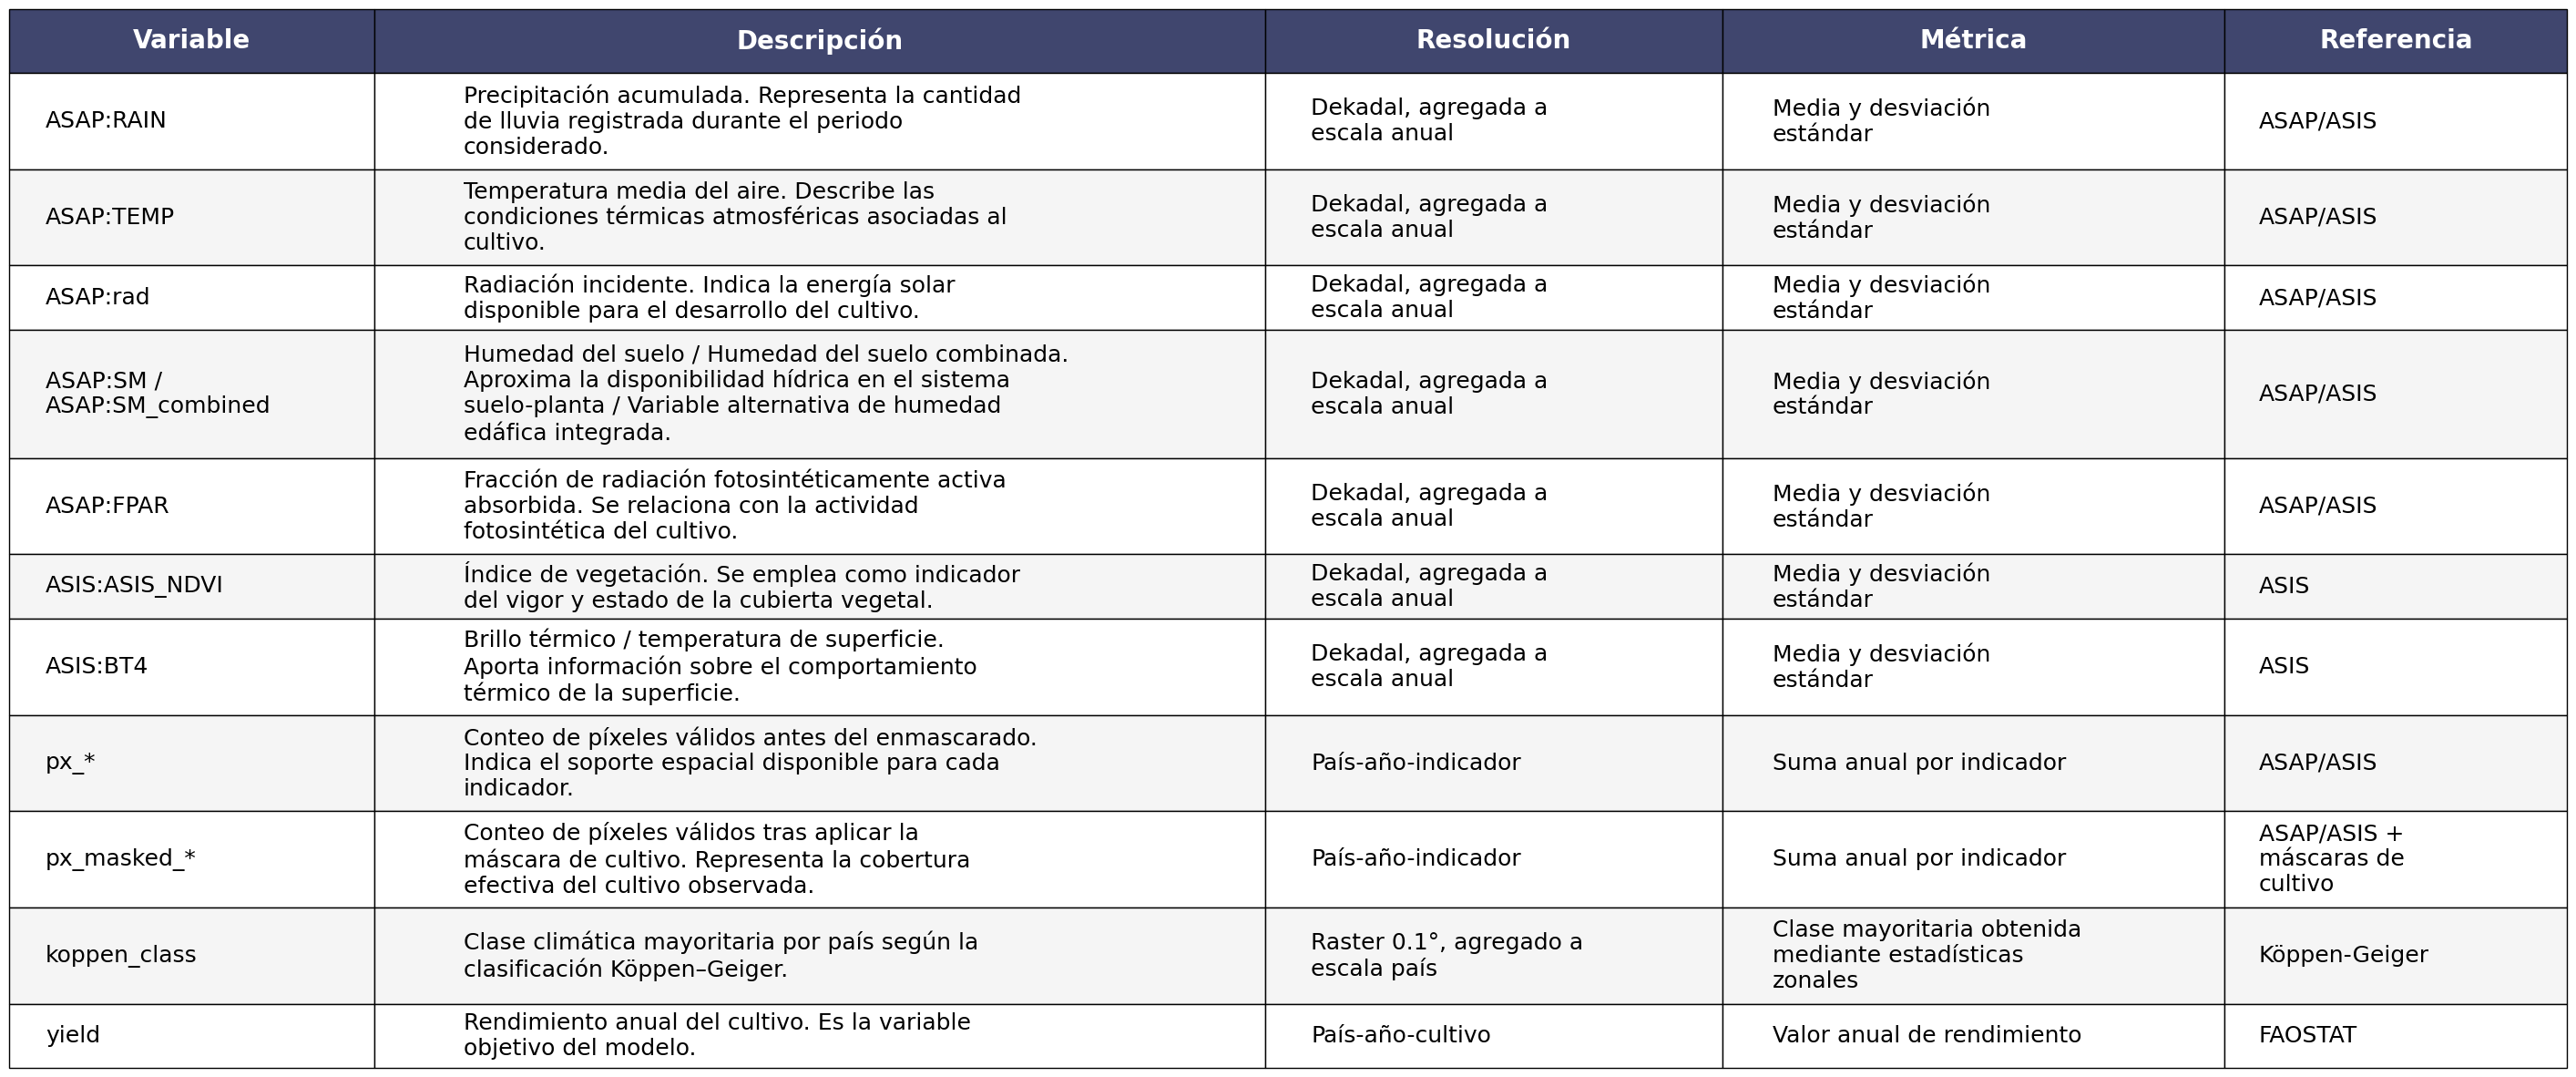

,Variable,Descripción,Resolución,Métrica,Referencia
0,ASAP:RAIN,Precipitación acumulada. Representa la cantida...,"Dekadal, agregada a\nescala anual",Media y desviación\nestándar,ASAP/ASIS
1,ASAP:TEMP,Temperatura media del aire. Describe las\ncond...,"Dekadal, agregada a\nescala anual",Media y desviación\nestándar,ASAP/ASIS
2,ASAP:rad,Radiación incidente. Indica la energía solar\n...,"Dekadal, agregada a\nescala anual",Media y desviación\nestándar,ASAP/ASIS
3,ASAP:SM /\nASAP:SM_combined,Humedad del suelo / Humedad del suelo combinad...,"Dekadal, agregada a\nescala anual",Media y desviación\nestándar,ASAP/ASIS
4,ASAP:FPAR,Fracción de radiación fotosintéticamente activ...,"Dekadal, agregada a\nescala anual",Media y desviación\nestándar,ASAP/ASIS
5,ASIS:ASIS_NDVI,Índice de vegetación. Se emplea como indicador...,"Dekadal, agregada a\nescala anual",Media y desviación\nestándar,ASIS
6,ASIS:BT4,Brillo térmico / temperatura de superficie.\nA...,"Dekadal, agregada a\nescala anual",Media y desviación\nestándar,ASIS
7,px_*,Conteo de píxeles válidos antes del enmascarad...,País-año-indicador,Suma anual por indicador,ASAP/ASIS
8,px_masked_*,Conteo de píxeles válidos tras aplicar la\nmás...,País-año-indicador,Suma anual por indicador,ASAP/ASIS +\nmáscaras de\ncultivo
9,koppen_class,Clase climática mayoritaria por país según la\...,"Raster 0.1°, agregado a\nescala país",Clase mayoritaria obtenida\nmediante estadísti...,Köppen-Geiger


In [134]:
tabla_variables_42 = crear_tabla_variables_42()
tabla_variables_42

In [135]:
# Observamos en qué columnas se observan valores faltantes
print("Valores faltantes en df_obs_data:")
print(df_obs_data.isnull().sum())

Valores faltantes en df_obs_data:
asap_unit_id                     0
year                             0
mean_ASAP:FPAR                1456
mean_ASAP:RAIN                   0
mean_ASAP:SM                    10
mean_ASAP:SM_combined            0
mean_ASAP:TEMP                   0
mean_ASAP:rad                    0
mean_ASIS:ASIS_NDVI              0
mean_ASIS:BT4                    0
std_ASAP:FPAR                 1456
std_ASAP:RAIN                    0
std_ASAP:SM                     10
std_ASAP:SM_combined             0
std_ASAP:TEMP                    0
std_ASAP:rad                     0
std_ASIS:ASIS_NDVI               0
std_ASIS:BT4                     0
px_ASAP:FPAR                  1456
px_ASAP:RAIN                     0
px_ASAP:SM                      10
px_ASAP:SM_combined              0
px_ASAP:TEMP                     0
px_ASAP:rad                      0
px_ASIS:ASIS_NDVI                0
px_ASIS:BT4                      0
px_masked_ASAP:FPAR           1456
px_masked_ASAP:RAIN  

In [136]:
# Rellenamos valores faltantes con la mediana del grupo
for var in ["mean_ASAP:FPAR", "std_ASAP:FPAR", "px_ASAP:FPAR", "px_masked_ASAP:FPAR",
            "mean_ASAP:SM", "std_ASAP:SM", "px_ASAP:SM", "px_masked_ASAP:SM"]:
    df_obs_data[var] = df_obs_data.groupby("asap_unit_id")[var].transform(lambda x: x.fillna(x.median()))


In [137]:
# Guardamos el DataFrame final
df_obs_data.to_csv("./CleanData/df_obs_data.csv", index=False)
print("DataFrame guardado como df_obs_data.csv")

DataFrame guardado como df_obs_data.csv


#### Preparamos los datos de producción

In [138]:
# Cargamos los datos de producción de cada tipo de cultivo
prod_info_maize = pd.read_csv("./Data/yield_data/yield_data_Maize (corn).csv")
prod_info_rice = pd.read_csv("./Data/yield_data/yield_data_Rice.csv")
prod_info_wheat = pd.read_csv("./Data/yield_data/yield_data_Wheat.csv")

In [139]:
# Visualizamos las primeras filas de cada DataFrame
print("Producción de Maíz:") 
print(prod_info_maize.head(), "\n")
print("Producción de Arroz:")
print(prod_info_rice.head(), "\n")
print("Producción de Trigo:")
print(prod_info_wheat.head(), "\n")

Producción de Maíz:
     country          crop  year   yield
0  Argentina  Maize (corn)  1961  1767.2
1  Argentina  Maize (corn)  1962  1893.6
2  Argentina  Maize (corn)  1963  1648.1
3  Argentina  Maize (corn)  1964  1801.0
4  Argentina  Maize (corn)  1965  1678.5 

Producción de Arroz:
      country  crop  year   yield
0  Bangladesh  Rice  1961  1700.5
1  Bangladesh  Rice  1962  1530.2
2  Bangladesh  Rice  1963  1769.0
3  Bangladesh  Rice  1964  1707.0
4  Bangladesh  Rice  1965  1682.7 

Producción de Trigo:
     country   crop  year   yield
0  Argentina  Wheat  1961  1295.0
1  Argentina  Wheat  1962  1522.2
2  Argentina  Wheat  1963  1575.1
3  Argentina  Wheat  1964  1835.3
4  Argentina  Wheat  1965  1321.2 



In [140]:
id_maize = EXT_Maize[["asap0_id", "name0_shr"]].rename(columns={"name0_shr": "country", "asap0_id": "asap_unit_id"})
id_rice = EXT_Rice[["asap0_id", "name0_shr"]].rename(columns={"name0_shr": "country", "asap0_id": "asap_unit_id"})
id_wheat = EXT_Wheat[["asap0_id", "name0_shr"]].rename(columns={"name0_shr": "country", "asap0_id": "asap_unit_id"})

In [141]:
prod_maize_final = prod_info_maize.merge(id_maize, on="country", how="left")
prod_rice_final = prod_info_rice.merge(id_rice, on="country", how="left")
prod_wheat_final = prod_info_wheat.merge(id_wheat, on="country", how="left")

In [142]:
print("Información general sobre los DataFrames de producción:")
print(prod_maize_final.info())
print(prod_rice_final.info())
print(prod_wheat_final.info())


Información general sobre los DataFrames de producción:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1364 entries, 0 to 1363
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       1364 non-null   object 
 1   crop          1364 non-null   object 
 2   year          1364 non-null   int64  
 3   yield         1364 non-null   float64
 4   asap_unit_id  1364 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 53.4+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       1116 non-null   object 
 1   crop          1116 non-null   object 
 2   year          1116 non-null   int64  
 3   yield         1116 non-null   float64
 4   asap_unit_id  1116 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 43.7+ KB

#### Combinamos los datos de producción y los datos de observación de la tierra

In [143]:
df_maize_final = df_obs_data.merge(prod_maize_final, on=["asap_unit_id", "year"], how="inner")
df_rice_final = df_obs_data.merge(prod_rice_final, on=["asap_unit_id", "year"], how="inner")
df_wheat_final = df_obs_data.merge(prod_wheat_final, on=["asap_unit_id", "year"], how="inner")

# Visualizamos los DataFrames finales y su información
print("DataFrame final de Maíz:")
print(df_maize_final.head(), "\n")
print(df_maize_final.info(), "\n")  
print("DataFrame final de Arroz:")
print(df_rice_final.head(), "\n")
print(df_rice_final.info(), "\n")
print("DataFrame final de Trigo:")
print(df_wheat_final.head(), "\n")
print(df_wheat_final.info(), "\n")

DataFrame final de Maíz:
   asap_unit_id  year  mean_ASAP:FPAR  mean_ASAP:RAIN  mean_ASAP:SM  \
0            41  1984       53.888647       54.665893      0.277685   
1            41  1985       53.888647       48.624003      0.275522   
2            41  1986       53.888647       49.286758      0.273614   
3            41  1987       53.888647       48.611285      0.266157   
4            41  1988       53.888647       46.851524      0.270388   

   mean_ASAP:SM_combined  mean_ASAP:TEMP  mean_ASAP:rad  mean_ASIS:ASIS_NDVI  \
0               0.282407       23.225820  173414.084765           165.034489   
1               0.280367       23.247559  170343.891754           170.169166   
2               0.279942       23.226513  172019.825200           176.895407   
3               0.274092       23.754767  176369.239443           173.025655   
4               0.280807       23.611726  172474.727567           165.929246   

   mean_ASIS:BT4  ...  px_masked_ASAP:SM  px_masked_ASAP:SM_combine

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   asap_unit_id                702 non-null    int64  
 1   year                        702 non-null    int64  
 2   mean_ASAP:FPAR              702 non-null    float64
 3   mean_ASAP:RAIN              702 non-null    float64
 4   mean_ASAP:SM                702 non-null    float64
 5   mean_ASAP:SM_combined       702 non-null    float64
 6   mean_ASAP:TEMP              702 non-null    float64
 7   mean_ASAP:rad               702 non-null    float64
 8   mean_ASIS:ASIS_NDVI         702 non-null    float64
 9   mean_ASIS:BT4               702 non-null    float64
 10  std_ASAP:FPAR               702 non-null    float64
 11  std_ASAP:RAIN               702 non-null    float64
 12  std_ASAP:SM                 702 non-null    float64
 13  std_ASAP:SM_combined        702 non

## Guardamos los datos tratados

In [144]:
df_maize_final.to_csv("./CleanData/df_maize_final.csv", index=False)
df_rice_final.to_csv("./CleanData/df_rice_final.csv", index=False)
df_wheat_final.to_csv("./CleanData/df_wheat_final.csv", index=False)
print("DataFrames finales guardados como df_maize_final.csv, df_rice_final.csv y df_wheat_final.csv")

DataFrames finales guardados como df_maize_final.csv, df_rice_final.csv y df_wheat_final.csv


## Análisis Exploratorio de los Datos

In [145]:
def plot_corr_matrix(df, title, guardar=True):
    cols_to_exclude = [col for col in ["asap_unit_id", "year"] if col in df.columns]

    df_numeric = (df.select_dtypes(include=["float64", "int64"]).drop(columns=cols_to_exclude))

    corr = df_numeric.corr()

    plt.figure(figsize=(22, 18))

    ax = sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        annot=False,
        fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8, "label": "Coeficiente de correlación"}
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.tick_params(
        axis="x",
        labelsize=16,
        rotation=90
    )

    ax.tick_params(
        axis="y",
        labelsize=16,
        rotation=0
    )

    # Colorbar
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label(
        "Coeficiente de correlación",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()

    if guardar:
        plt.savefig(
            f"Figuras/corr_matrix_{title.lower()}.svg",
            format="svg",
            bbox_inches="tight"
        )

        plt.savefig(
            f"Figuras/corr_matrix_{title.lower()}.pdf",
            format="pdf",
            bbox_inches="tight"
        )

    plt.show()

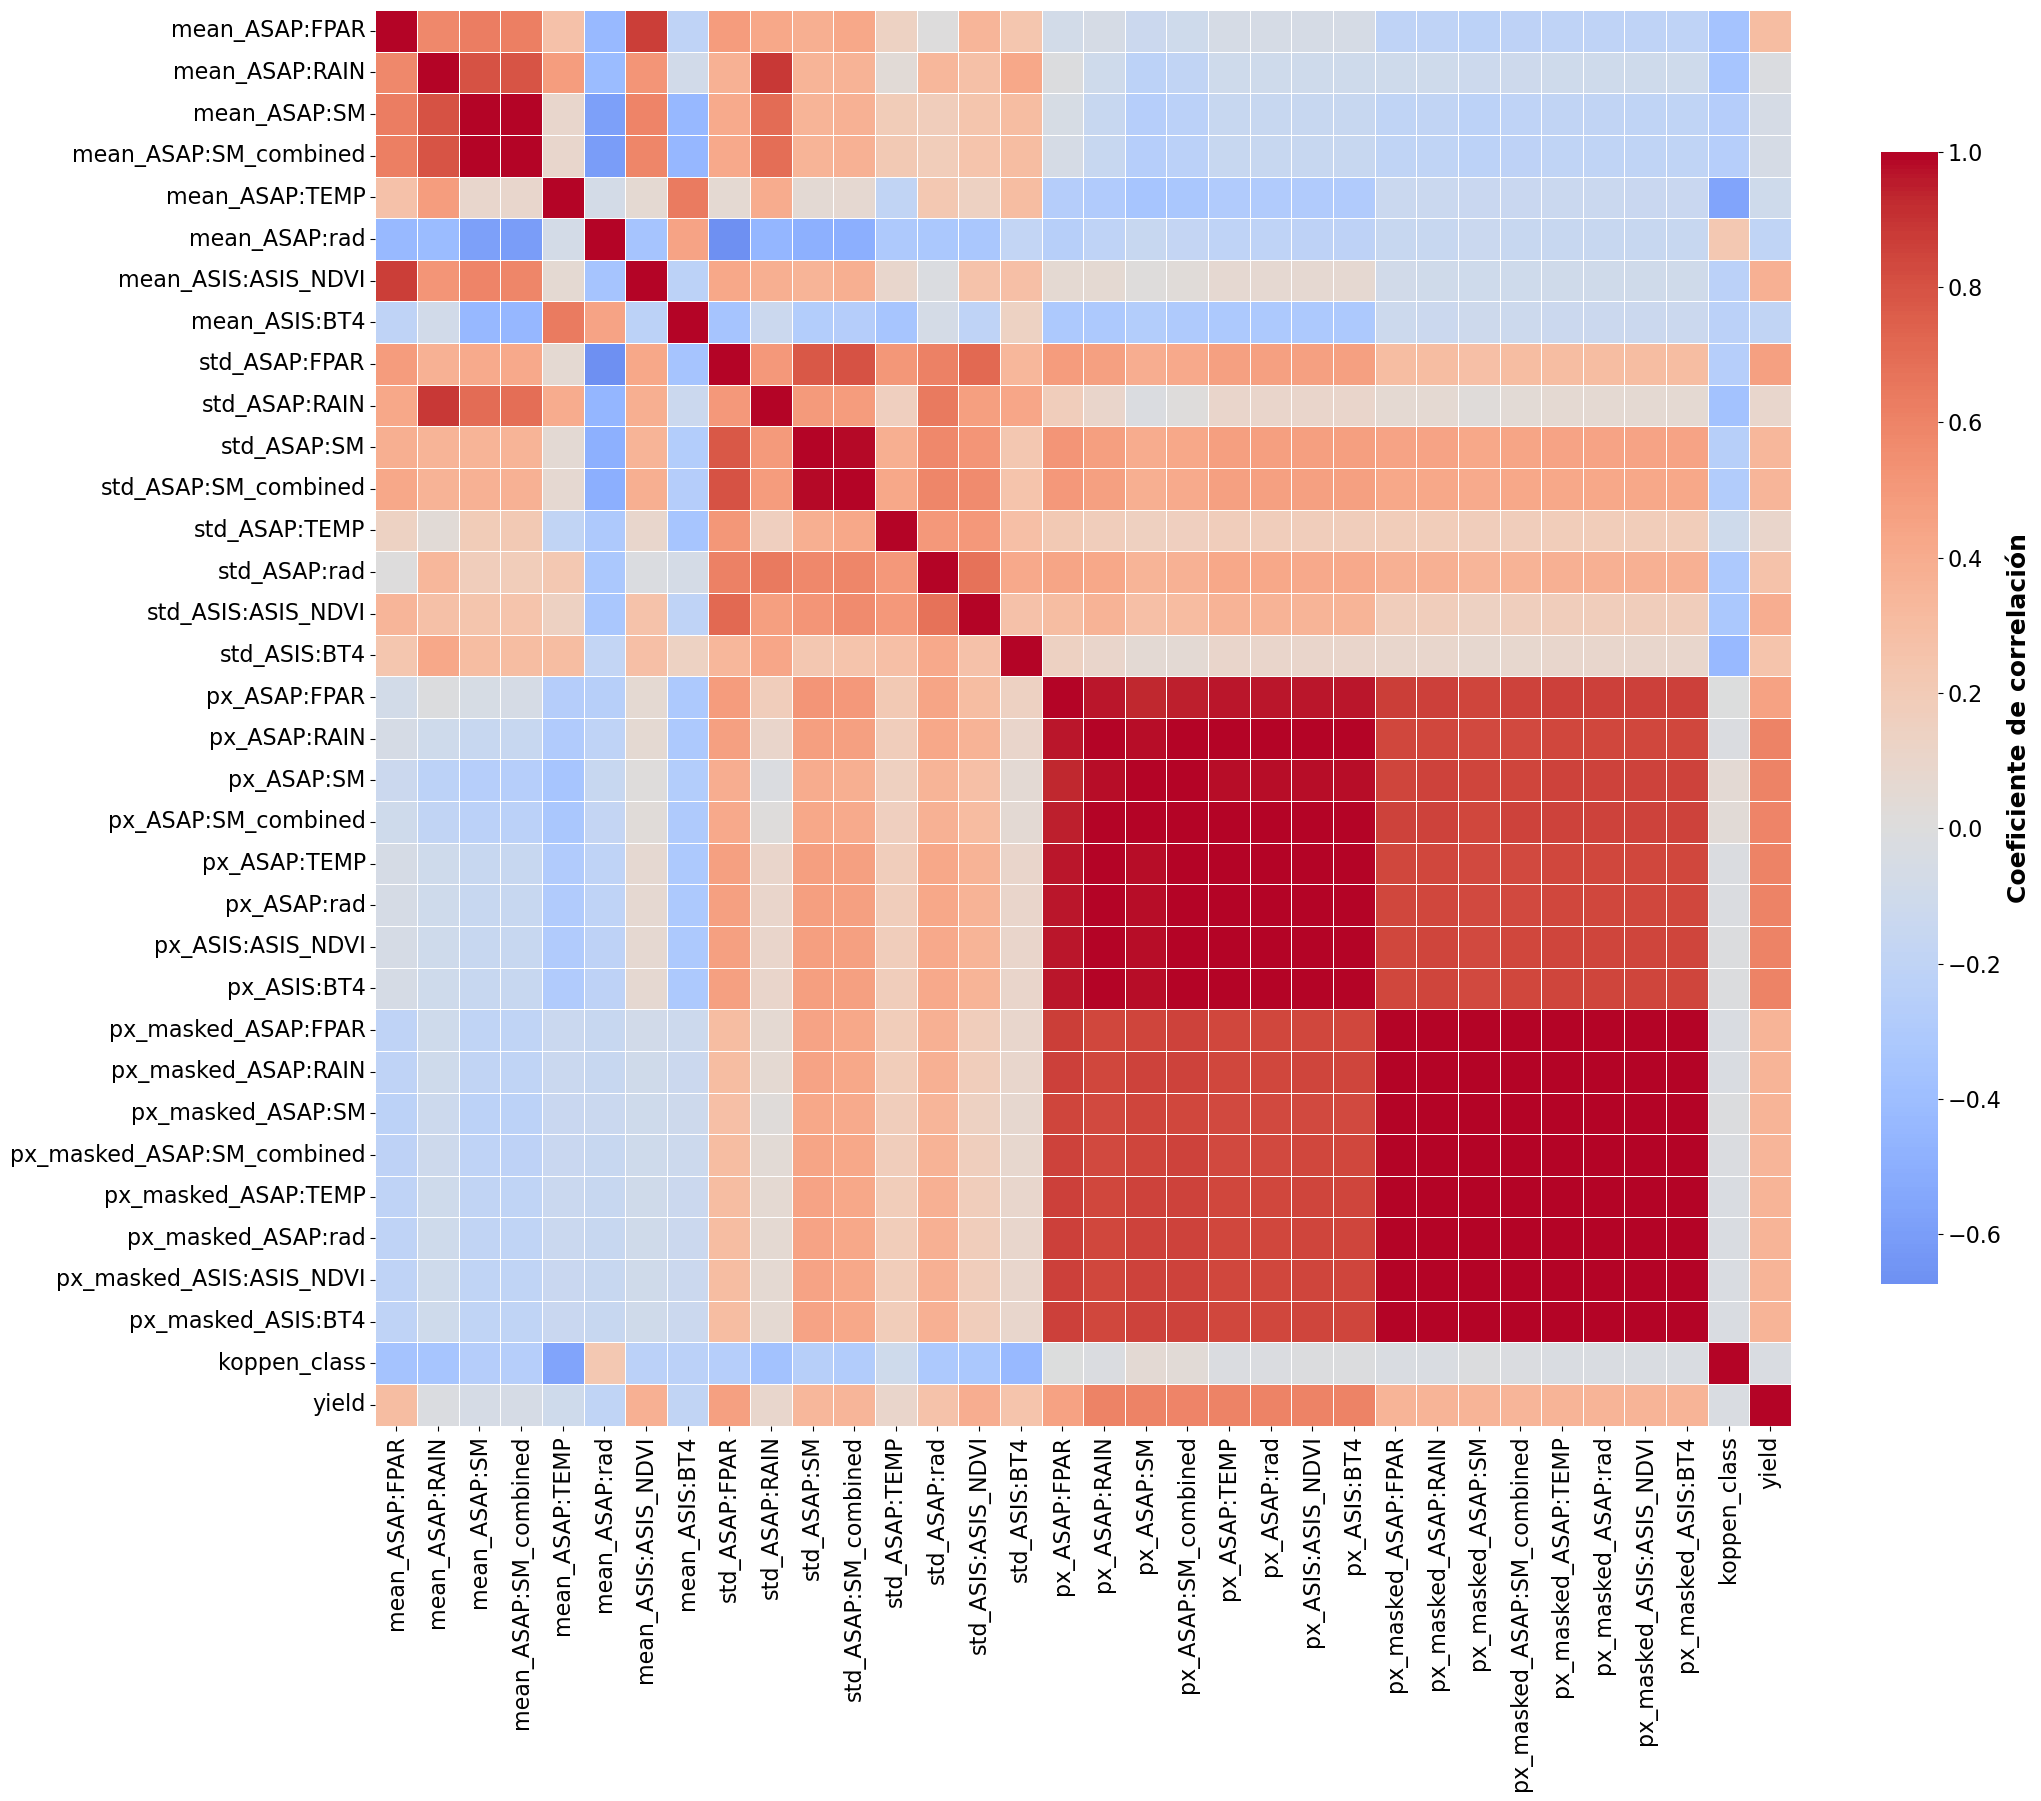

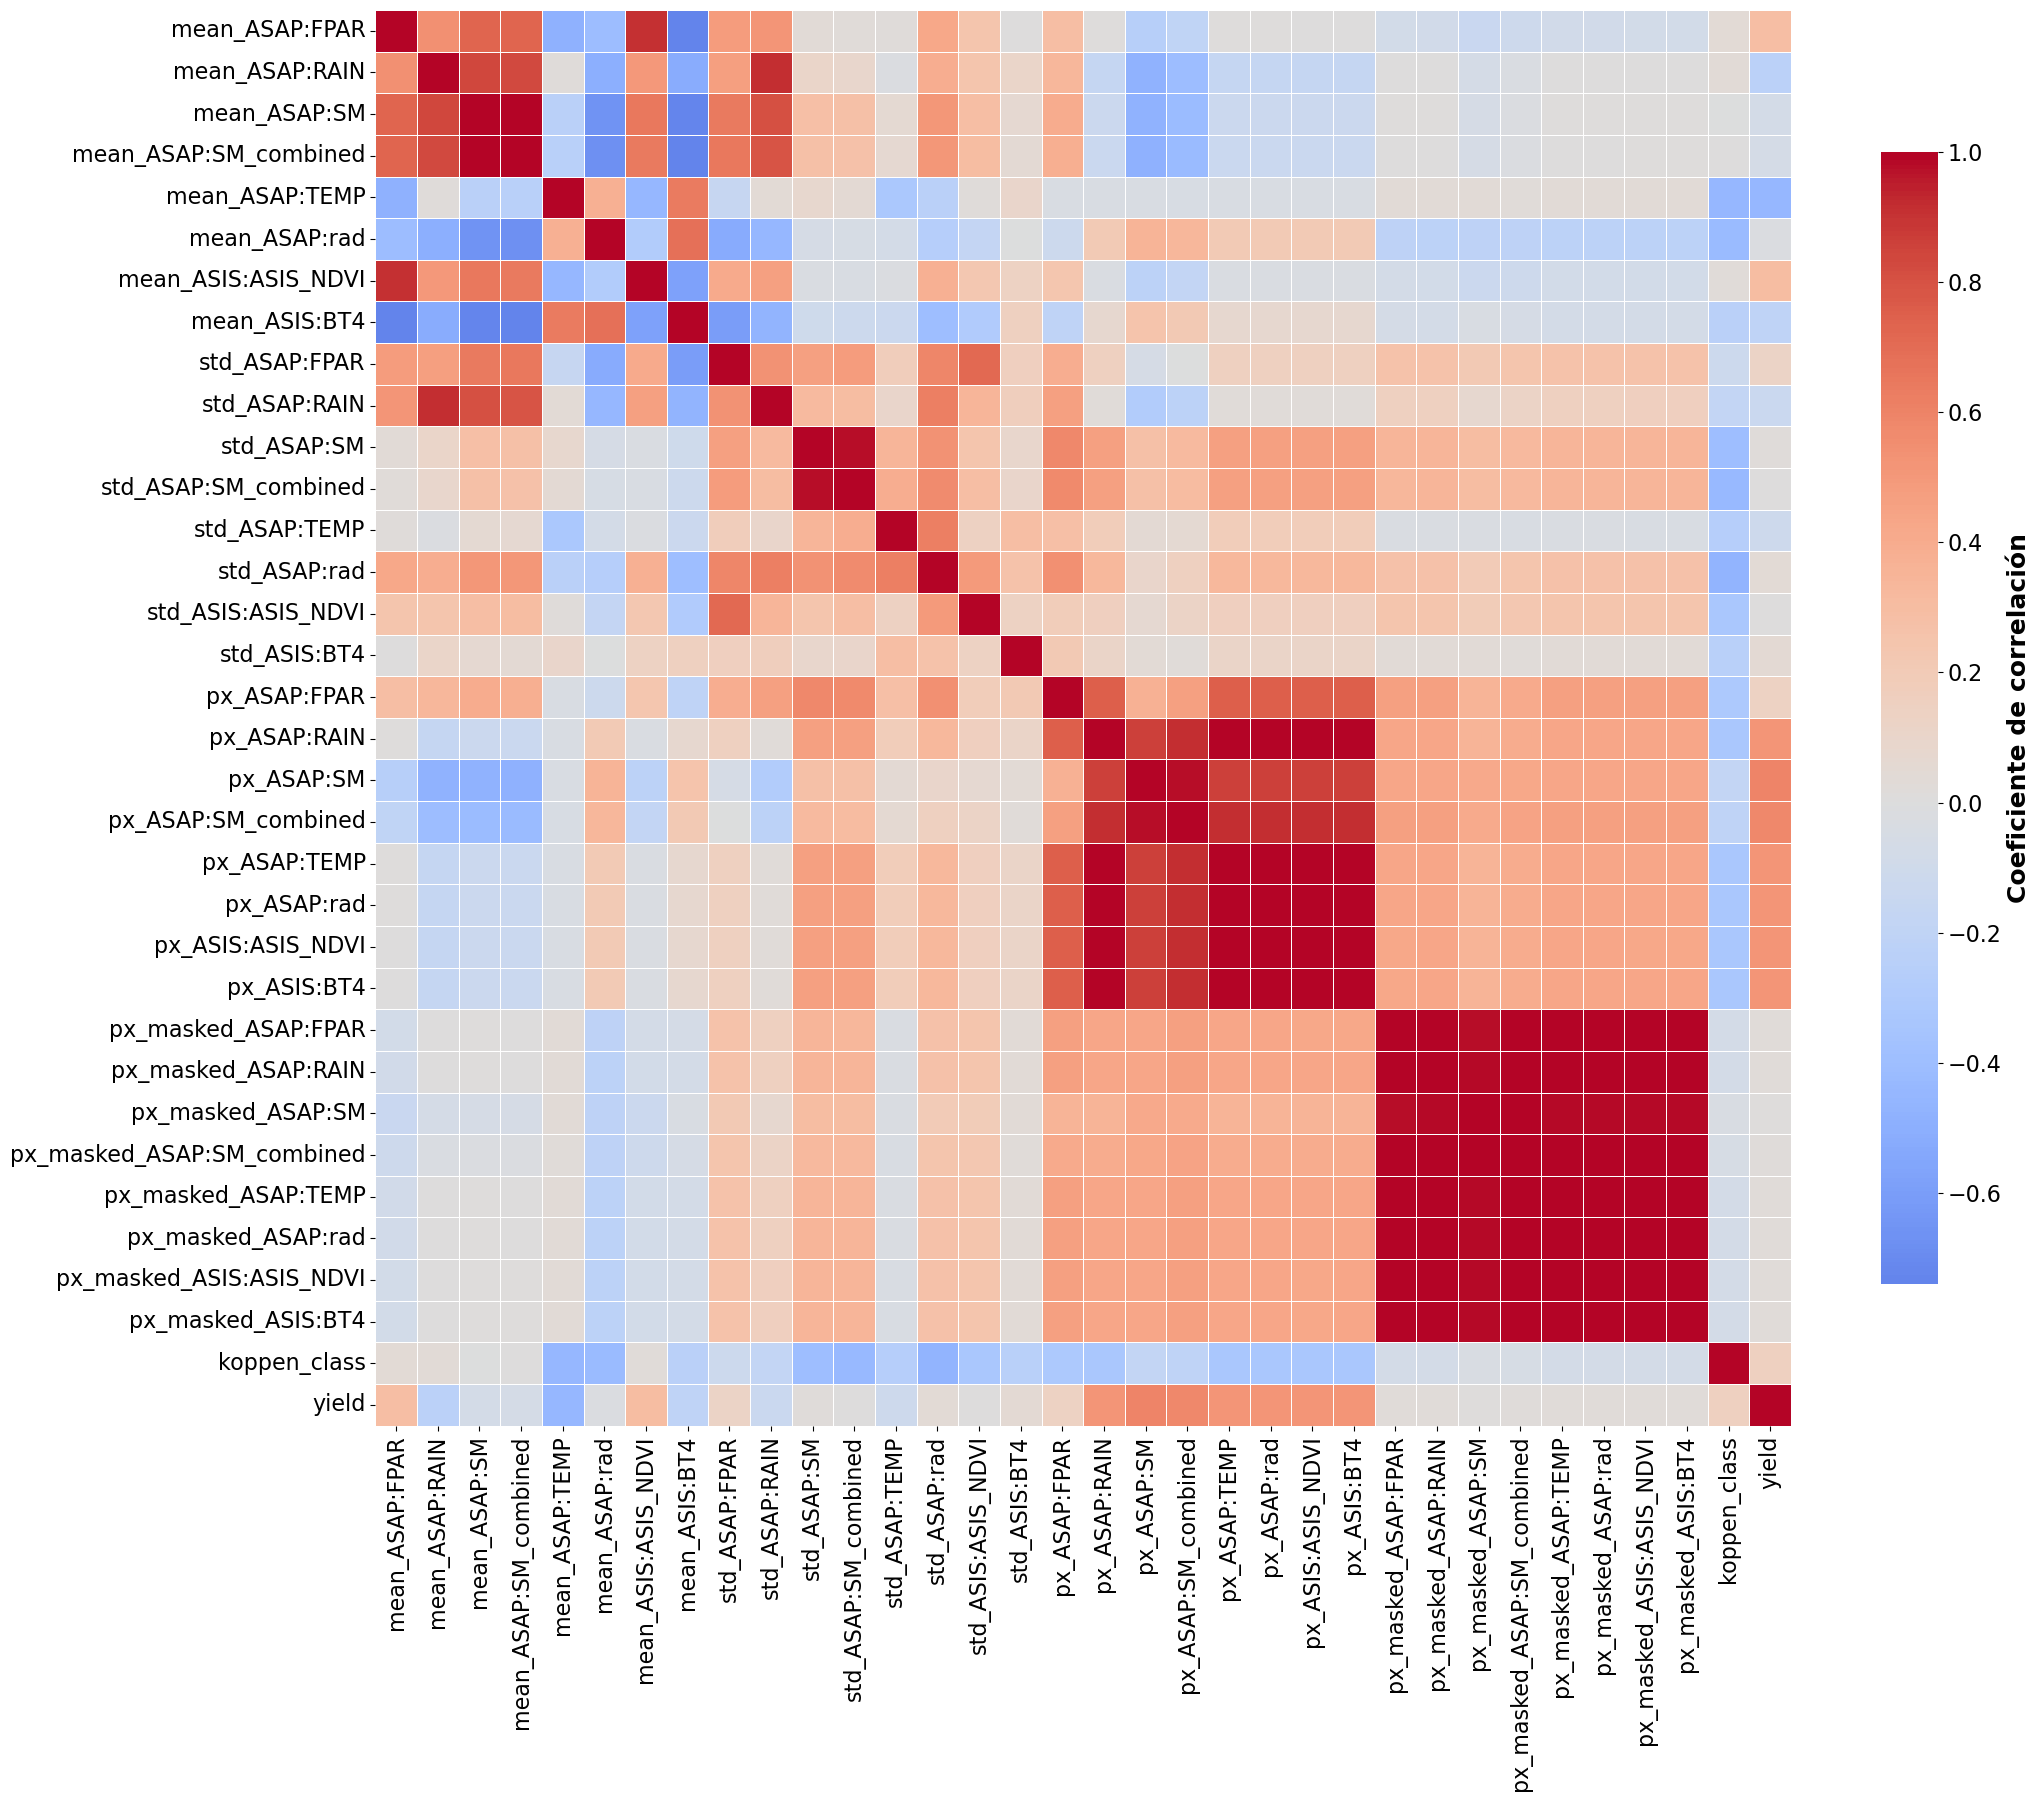

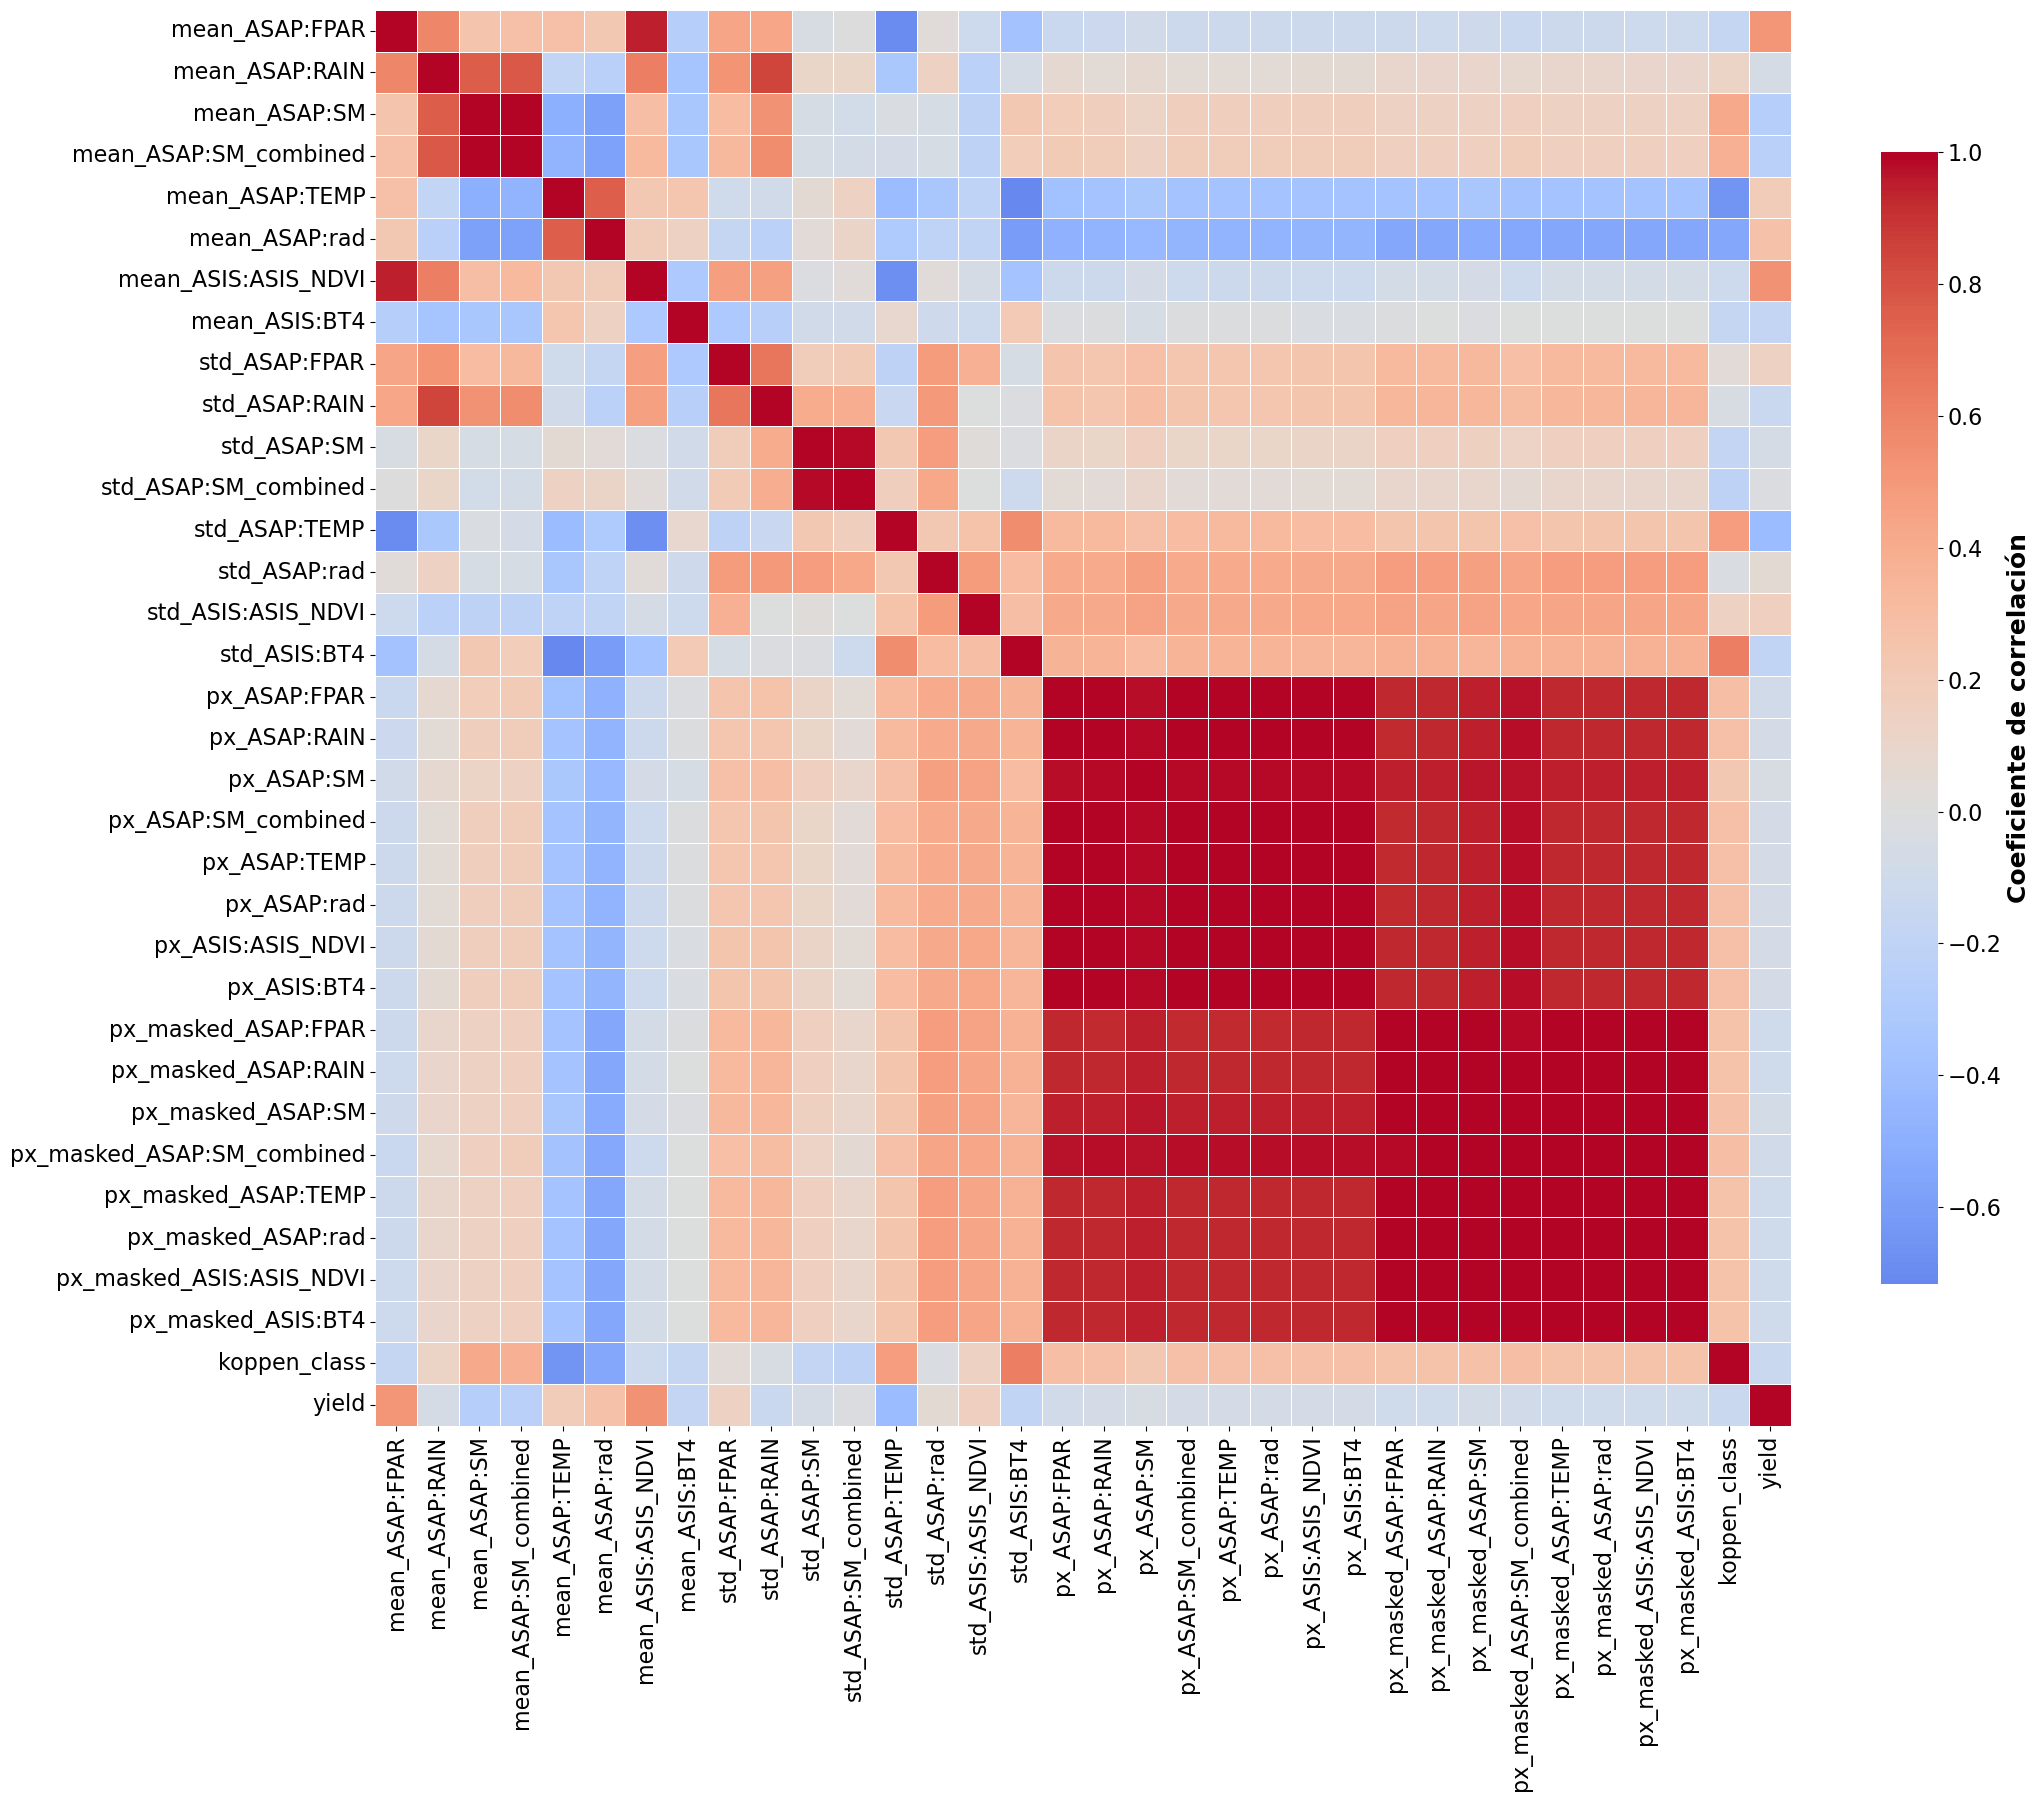

In [146]:
# Generar los mapas de calor de correlación para cada dataframe
plot_corr_matrix(df_maize_final, "Maíz")
plot_corr_matrix(df_rice_final, "Arroz")
plot_corr_matrix(df_wheat_final, "Trigo")

### Observaciones

#### · Maíz

    - Las variables '*:SM' y '*:SM_combined'; y las variables 'px_*' y 'px_masked_*' presentan correlaciones altas entre ellas.
    - Las variables 'mean_ASAP:TEMP' y 'mean_ASIS:BT4' tienen una correlación positiva moderada puesto que ambas miden temperatura.
    - Ninguna variable tiene correlación fuerte con 'yield', pero sí observamos correlaciones positivas.

#### · Arroz

    - Parecido a Maíz para el caso de las variables '*:SM' & '*:SM_combined' y 'px_*' & 'px_masked_*', presentan redundancia entre ellas.
    - Correlaciones fuertes destacables entre 'mean_ASIS:ASIS_NDVI' & 'mean_ASAP:FPAR'.
    - Observamos correlación negativa entre 'yield' y 'mean_ASAP:TEMP'.

#### · Trigo

    - Igual que en los casos anteriores para las variables '*:SM' y '*:SM_combined'; y las variables 'px_*' y 'px_masked_*'.
    - El resto de correlaciones no difieren mucho de los casos anteriores, salvo que hay menos correlaciones negativas o son más leves.
    - Observamos correlaciones positivas moderadas entre 'yield' y 'mean_ASAP:FPAR' y 'mean_ASIS:ASIS_NDVI'.

In [147]:
maiz = df_maize_final.copy()
arroz = df_rice_final.copy()
trigo = df_wheat_final.copy()

In [148]:
maiz_clean = maiz.loc[:, ~(maiz.columns.str.startswith("px_") |  maiz.columns.str.endswith(":SM"))].copy()
arroz_clean = arroz.loc[:, ~(arroz.columns.str.startswith("px_") | arroz.columns.str.endswith(":SM"))].copy()
trigo_clean = trigo.loc[:, ~(trigo.columns.str.startswith("px_") | trigo.columns.str.endswith(":SM"))].copy()

Creamos nuevos Data Frames sin las columnas "px", "px_masked" & ":SM"

### Preparación de los datos

Como preparación de los datos para su análisis eliminaremos las variables irrelevantes para el estudio: 'asap_unit_id', 'year', 'country' & 'crop'.

In [149]:
# Eliminamos columnas irrelevantes
cols_to_drop = ["asap_unit_id", "year", "country", "crop"]
maiz_clean = maiz_clean.drop(columns=cols_to_drop)
arroz_clean = arroz_clean.drop(columns=cols_to_drop)
trigo_clean = trigo_clean.drop(columns=cols_to_drop)

### RandomForestRegressor

Emplearemos este modelo para identificar variables importantes en la predicción de 'yield' para un posterior modelado.

In [150]:
# División de los DataFrames en variables predictoras (X) y variable objetivo (y)
X_maiz = maiz_clean[[col for col in maiz_clean.columns if col != "yield"]]
y_maiz = maiz_clean["yield"]

X_arroz = arroz_clean[[col for col in arroz_clean.columns if col != "yield"]]
y_arroz = arroz_clean["yield"]

X_trigo = trigo_clean[[col for col in trigo_clean.columns if col != "yield"]]
y_trigo = trigo_clean["yield"]

# Visualizamos las primeras filas de las variables predictoras y la variable objetivo
print("Variables predictoras y objetivo para Maíz:")
print(X_maiz.head())
print(y_maiz.head())


Variables predictoras y objetivo para Maíz:
   mean_ASAP:FPAR  mean_ASAP:RAIN  mean_ASAP:SM_combined  mean_ASAP:TEMP  \
0       53.888647       54.665893               0.282407       23.225820   
1       53.888647       48.624003               0.280367       23.247559   
2       53.888647       49.286758               0.279942       23.226513   
3       53.888647       48.611285               0.274092       23.754767   
4       53.888647       46.851524               0.280807       23.611726   

   mean_ASAP:rad  mean_ASIS:ASIS_NDVI  mean_ASIS:BT4  std_ASAP:FPAR  \
0  173414.084765           165.034489     141.818289      12.969789   
1  170343.891754           170.169166     144.470602      12.969789   
2  172019.825200           176.895407     145.896650      12.969789   
3  176369.239443           173.025655     145.889250      12.969789   
4  172474.727567           165.929246     143.883598      12.969789   

   std_ASAP:RAIN  std_ASAP:SM_combined  std_ASAP:TEMP  std_ASAP:rad  \
0

In [151]:
# training y test split
X_train_maiz, X_test_maiz, y_train_maiz, y_test_maiz = train_test_split(X_maiz, y_maiz, test_size=0.2, random_state=42)
X_train_arroz, X_test_arroz, y_train_arroz, y_test_arroz = train_test_split(X_arroz, y_arroz, test_size=0.2, random_state=42)
X_train_trigo, X_test_trigo, y_train_trigo, y_test_trigo = train_test_split(X_trigo, y_trigo, test_size=0.2, random_state=42)

In [152]:
# Entrenamos los modelos de Random Forests
rf_maiz = RandomForestRegressor(n_estimators=100, random_state=42)
rf_arroz = RandomForestRegressor(n_estimators=100, random_state=42)
rf_trigo = RandomForestRegressor(n_estimators=100, random_state=42)

rf_maiz.fit(X_train_maiz, y_train_maiz)
rf_arroz.fit(X_train_arroz, y_train_arroz)
rf_trigo.fit(X_train_trigo, y_train_trigo)

RandomForestRegressor(random_state=42)

#### Importancia de las variables

Una vez entrenados los modelos, extraemos los cálculos en forma de Data Frame ordenado.

In [153]:
# Extraemos las características más importantes de cada modelo
imp_maiz = rf_maiz.feature_importances_
imp_arroz = rf_arroz.feature_importances_
imp_trigo = rf_trigo.feature_importances_

features_maiz = X_train_maiz.columns
features_arroz = X_train_arroz.columns
features_trigo = X_train_trigo.columns

# Creamos Data frames ordenados por importancia:
df_imp_maiz = pd.DataFrame({"feature": features_maiz, "importance": imp_maiz}).sort_values(by="importance", ascending=False)
df_imp_arroz = pd.DataFrame({"feature": features_arroz, "importance": imp_arroz}).sort_values(by="importance", ascending=False)
df_imp_trigo = pd.DataFrame({"feature": features_trigo, "importance": imp_trigo}).sort_values(by="importance", ascending=False)

#### Visualizamos las características más importantes de cada cultivo

In [154]:
def plot_feature_importance(df, title):
    plt.figure(figsize=(12, 6))
    sns.barplot(x="importance", y="feature", data=df.head(10), palette="viridis")
    plt.title(f"Importancia de las características: {title}")
    plt.xlabel("Importancia")
    plt.ylabel("Características")
    plt.show()

C:\Users\Nacor Olmos\AppData\Local\Temp\ipykernel_26128\242775040.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=df.head(10), palette="viridis")


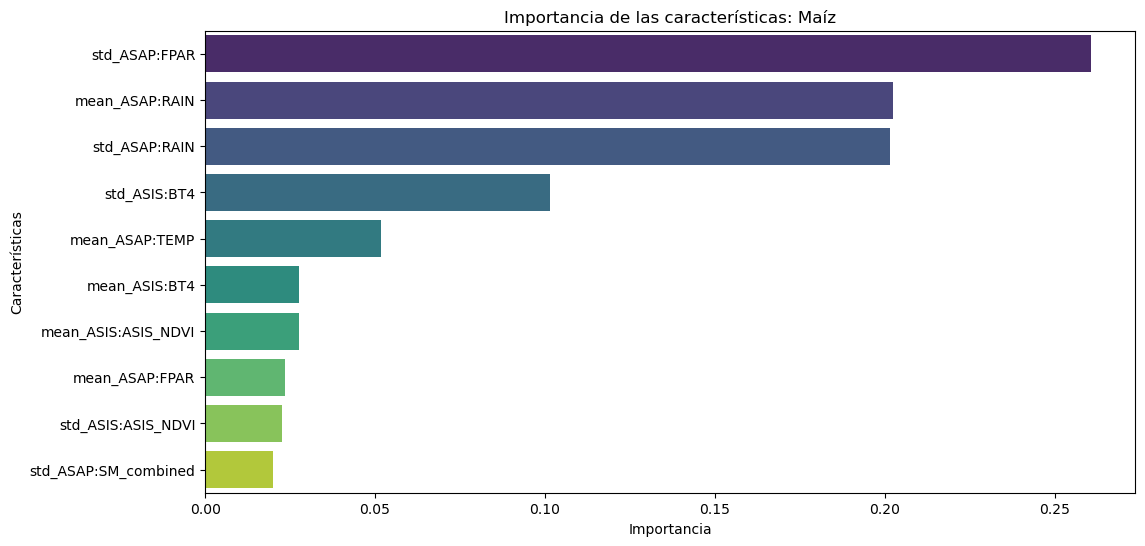

C:\Users\Nacor Olmos\AppData\Local\Temp\ipykernel_26128\242775040.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=df.head(10), palette="viridis")


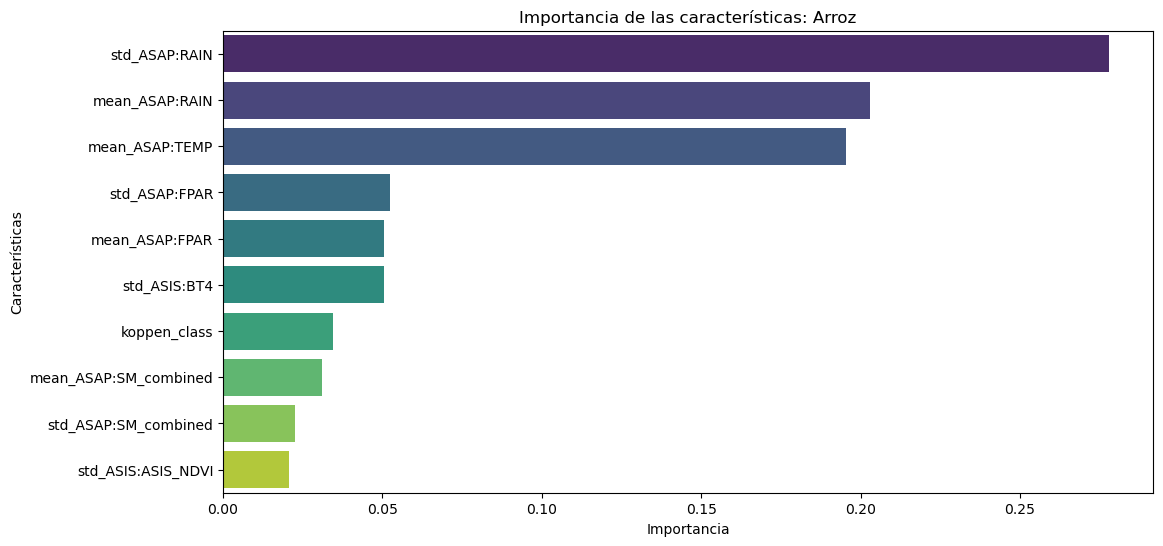

C:\Users\Nacor Olmos\AppData\Local\Temp\ipykernel_26128\242775040.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=df.head(10), palette="viridis")


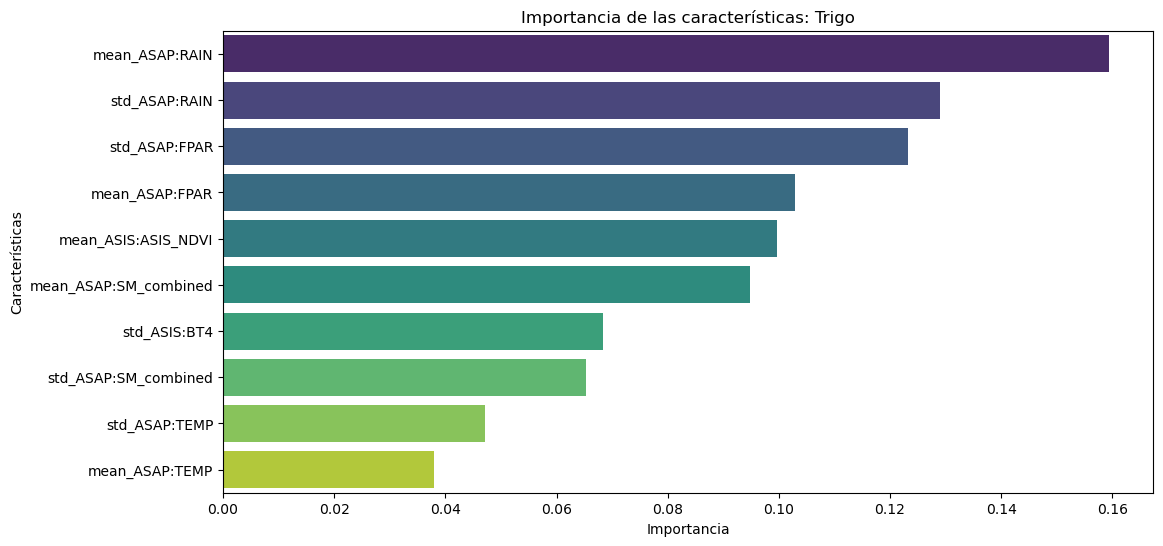

In [155]:
plot_feature_importance(df_imp_maiz, "Maíz")
plot_feature_importance(df_imp_arroz, "Arroz")
plot_feature_importance(df_imp_trigo, "Trigo")

#### Comparación de variables por cultivo

In [156]:
df_imp_maiz = df_imp_maiz.rename(columns={"importance": "importance_maiz"})
df_imp_arroz = df_imp_arroz.rename(columns={"importance": "importance_arroz"})
df_imp_trigo  = df_imp_trigo.rename(columns={"importance": "importance_trigo"})

# Unimos por tipo de variable
df_imp_final = df_imp_maiz.merge(df_imp_arroz, on="feature", how="outer").merge(df_imp_trigo, on="feature", how="outer").fillna(0)

# Ordenar por la suma total de importancia
df_imp_final["importance_total"] = df_imp_final["importance_maiz"] + df_imp_final["importance_arroz"] + df_imp_final["importance_trigo"]
df_imp_final = df_imp_final.sort_values(by="importance_total", ascending=False)

print("DataFrame final de importancias:")
print(df_imp_final.head(15))

DataFrame final de importancias:
                  feature  importance_maiz  importance_arroz  \
9           std_ASAP:RAIN         0.201508          0.277874   
2          mean_ASAP:RAIN         0.202543          0.202891   
8           std_ASAP:FPAR         0.260696          0.052280   
4          mean_ASAP:TEMP         0.051644          0.195361   
14           std_ASIS:BT4         0.101433          0.050442   
1          mean_ASAP:FPAR         0.023534          0.050578   
6     mean_ASIS:ASIS_NDVI         0.027705          0.014539   
3   mean_ASAP:SM_combined         0.012798          0.031066   
10   std_ASAP:SM_combined         0.019891          0.022726   
11          std_ASAP:TEMP         0.012783          0.013857   
13     std_ASIS:ASIS_NDVI         0.022657          0.020571   
7           mean_ASIS:BT4         0.027748          0.004777   
0            koppen_class         0.012554          0.034585   
5           mean_ASAP:rad         0.013337          0.012771   
12     

#### Mapa de calor

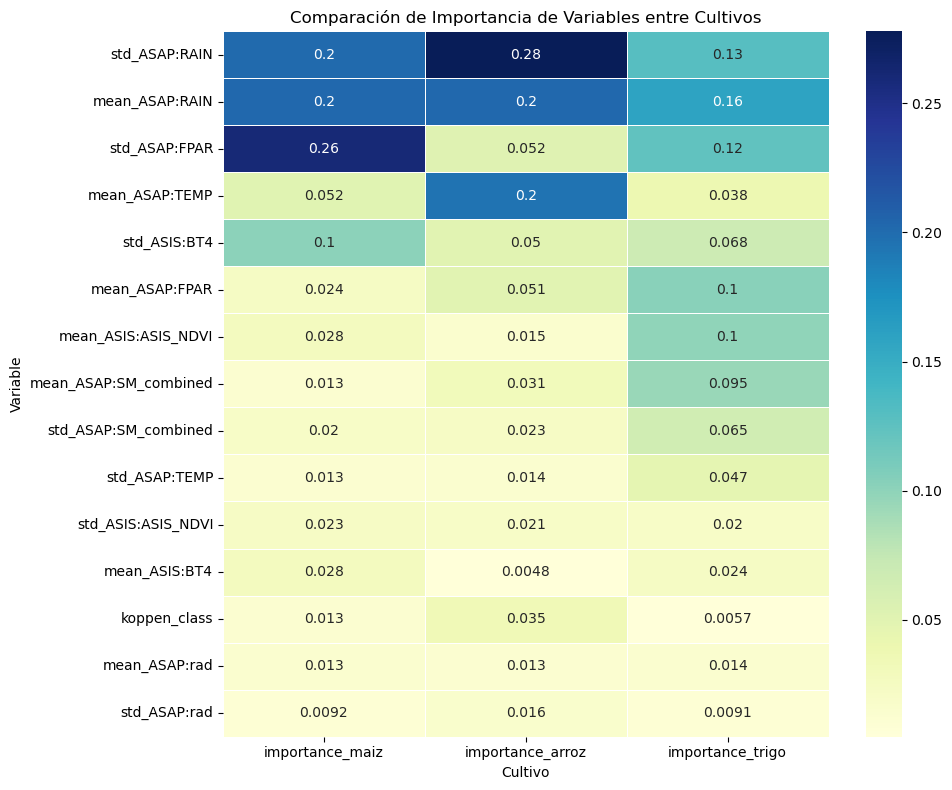

In [157]:
top = 15
df_heatmap = df_imp_final.copy()
df_heatmap = df_heatmap.drop(columns=["importance_total"]).head(15)

# Mapa de Calor de Importancia de Características
plt.figure(figsize=(10, 8))
sns.heatmap(df_heatmap.set_index("feature"), annot=True, cmap="YlGnBu", linewidths=0.5)
plt.title("Comparación de Importancia de Variables entre Cultivos")
plt.xlabel("Cultivo")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### Variables finales por cultivo

En el apartado de observaciones podemos apreciar que las variables 'mean_ASAP:FPAR'/'mean_ASIS:ASIS_NDVI' y 'mean_ASAP:RAIN'/'std_ASAP:RAIN', respectivamente, están muy correlacionadas entre ellas en los tres cultivos, por lo que eliminaremos la de menor importancia para cada caso de estudio.

In [158]:
cols_to_drop = ["asap_unit_id", "country", "crop"]

#### Maíz

In [159]:
mod_maiz = df_maize_final.copy().drop(columns=cols_to_drop)
mod_maiz = mod_maiz.loc[:, ~(mod_maiz.columns.str.startswith("px_") |  mod_maiz.columns.str.endswith(":SM") | mod_maiz.columns.str.fullmatch("mean_ASAP:FPAR") | mod_maiz.columns.str.fullmatch("std_ASAP:RAIN"))]

#### Arroz

In [160]:
mod_arroz = df_rice_final.copy().drop(columns=cols_to_drop)
mod_arroz = mod_arroz.loc[:, ~(mod_arroz.columns.str.startswith("px_") |  mod_arroz.columns.str.endswith(":SM") | mod_arroz.columns.str.fullmatch("mean_ASIS:ASIS_NDVI") | mod_arroz.columns.str.fullmatch("mean_ASAP:RAIN"))]

#### Trigo

In [161]:
mod_trigo = df_wheat_final.copy().drop(columns=cols_to_drop)
mod_trigo = mod_trigo.loc[:, ~(mod_trigo.columns.str.startswith("px_") |  mod_trigo.columns.str.endswith(":SM") | mod_trigo.columns.str.fullmatch("mean_ASIS:ASIS_NDVI") | mod_trigo.columns.str.fullmatch("std_ASAP:RAIN"))]

## Guardamos los datos finales para modelado por cultivo

In [162]:
mod_maiz.to_csv("./CleanData/mod_maiz.csv", index=False)
mod_arroz.to_csv("./CleanData/mod_arroz.csv", index=False)  
mod_trigo.to_csv("./CleanData/mod_trigo.csv", index=False)

## TRABAJO EXTRA (Anexo)

In [163]:
# =========================
# Mapamundi países del estudio
# =========================

import geopandas as gpd
import folium
import matplotlib.pyplot as plt

def _ids_paises_estudio(df_maize_final, df_rice_final, df_wheat_final):
    """Devuelve el conjunto de asap_unit_id presentes en los tres cultivos."""
    ids = []
    for df in [df_maize_final, df_rice_final, df_wheat_final]:
        if df is not None and len(df) > 0:
            ids.append(df["asap_unit_id"].dropna().astype(int).unique())
    if not ids:
        return set()
    import numpy as np
    return set(np.concatenate(ids).astype(int))



def mostrar_mapamundi_paises_estudio(
    df_maize_final,
    df_rice_final,
    df_wheat_final,
    ruta_shapefile="Data/gaul0_asap_shapefile/gaul0_asap.shp",
    interactive=True,
    color_estudio="#2E86DE",
    color_fondo="#E6E6E6"
):
    """
    Dibuja un mapamundi coloreando solo los países que aparecen en el estudio.
    
    Params
    ------
    df_maize_final, df_rice_final, df_wheat_final : pd.DataFrame
        DataFrames finales (ya combinados) que contienen la columna 'asap_unit_id'.
    ruta_shapefile : str
        Ruta al shapefile GAUL0-ASAP (campo clave: 'asap0_id').
    interactive : bool
        True -> devuelve un folium.Map interactivo; False -> grafico estático con matplotlib.
    color_estudio : str
        Color de relleno para países del estudio.
    color_fondo : str
        Color de relleno para países fuera del estudio (solo en modo estático).
    
    Returns
    -------
    folium.Map | matplotlib.axes.Axes
    """
    # 1) IDs presentes en el estudio
    ids_estudio = _ids_paises_estudio(df_maize_final, df_rice_final, df_wheat_final)
    if len(ids_estudio) == 0:
        raise ValueError("No se han encontrado 'asap_unit_id' en los DataFrames suministrados.")

    # 2) Cargar shapefile y marcar países del estudio
    gdf = gpd.read_file(ruta_shapefile)  # contiene 'asap0_id', 'adm0_name', 'geometry', etc.
    gdf["asap0_id"] = gdf["asap0_id"].astype(int)
    gdf["en_estudio"] = gdf["asap0_id"].isin(ids_estudio)

    # 3) Modo interactivo (folium)
    if interactive:
        m = folium.Map(location=[15, 0], zoom_start=2, tiles="cartodbpositron")
        # Capa solo con países del estudio
        gdf_estudio = gdf[gdf["en_estudio"]].copy()
        folium.GeoJson(
            gdf_estudio.to_json(),
            name="Países del estudio",
            style_function=lambda feat: {
                "fillColor": color_estudio,
                "color": "black",
                "weight": 0.6,
                "fillOpacity": 0.7
            },
            tooltip=folium.features.GeoJsonTooltip(fields=["adm0_name"], aliases=["País"])
        ).add_to(m)

        folium.LayerControl(collapsed=False).add_to(m)
        # Contador en consola
        print(f"Países del estudio destacados: {gdf_estudio.shape[0]}")
        return m

    # 4) Modo estático (matplotlib)
    fig, ax = plt.subplots(figsize=(14, 7))
    gdf.boundary.plot(ax=ax, color="white", linewidth=0.4)
    # Fondo gris claro para todos
    gdf.plot(ax=ax, color=color_fondo, linewidth=0)
    # Relleno azul solo para los del estudio
    gdf[gdf["en_estudio"]].plot(ax=ax, color=color_estudio, linewidth=0)
    ax.set_axis_off()
    # Contador en consola
    print(f"Países del estudio destacados: {gdf[gdf['en_estudio']].shape[0]}")

    plt.savefig(
                "Figuras/paises_estudio.svg",
                format="svg",
                bbox_inches="tight"
            )
    plt.savefig(
        "Figuras/paises_estudio.pdf",
        format="pdf",
        bbox_inches="tight"
    )

    return ax


In [164]:
# m = mostrar_mapamundi_paises_estudio(df_maize_final, df_rice_final, df_wheat_final, interactive=True)
# m  # muestra el mapa en la celda

Países del estudio destacados: 46


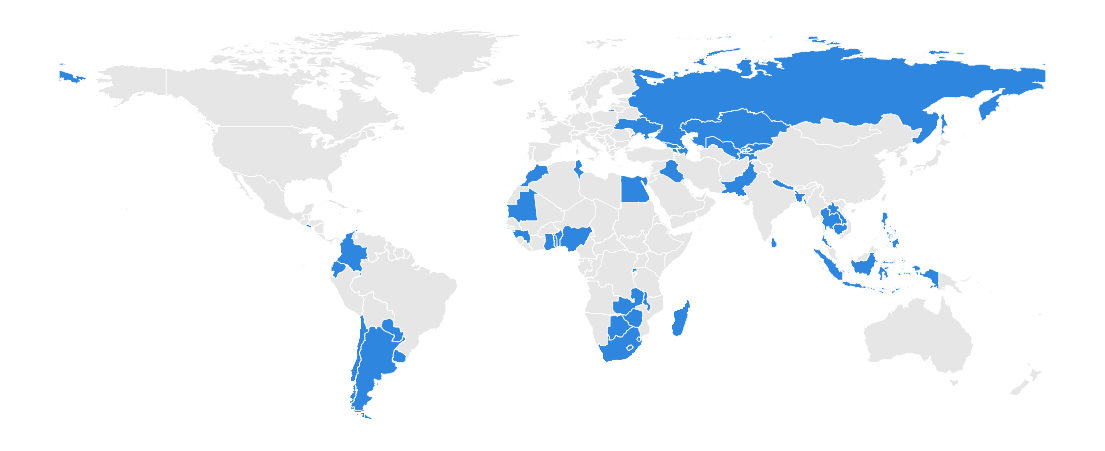

In [165]:
ax = mostrar_mapamundi_paises_estudio(df_maize_final, df_rice_final, df_wheat_final, interactive=False)
plt.show()